# [LAB-02] 비지도 학습ㅣ05-계층적 군집(실습코드).ipynb

# 계층적 군집이란

가장 가까운 것끼리 둘씩 계속 합쳐 나가는 방법

- 처음에는 데이터 하나하나가 각각 하나의 그룹이다 (100개 데이터 → 100개 그룹)
- 가장 가까운 두 그룹을 합친다 (99개 그룹)
- 이것을 전부 하나의 그룹이 될 때까지 반복한다
- 합쳐지는 과정을 나무 그림으로 그린 것이 **덴드로그램**

**진행 순서**: ① 가까운 두 그룹 찾기 → ② 두 그룹 합치기 → ③ 합친 것을 새 그룹으로 취급 → ④ 하나가 될 때까지 반복

## KMeans와의 차이

K를 미리 정해도 되고, 실행할 때마다 결과가 항상 같다
→ 가장 큰 장점: **"왜 이렇게 묶었는지 그림으로 보여줄 수 있다"**

| | K-Means | 계층적 군집 |
|---|---|---|
| K를 미리 정하나 | 정해야 한다 | 나중에 잘라도 된다 |
| 실행할 때마다 결과 | 달라질 수 있다 (랜덤 시작) | 항상 같다 |
| 과정을 볼 수 있나 | ✗ | ○ 덴드로그램 |
| 대용량 데이터 | 잘 된다 | ✗ 느리다 |

---

# 거리를 어떻게 잴 것인가

유클리드는 직선거리, 맨해튼은 바둑판 도로를 따라간 거리다

- **유클리디안 거리**: 직선 거리
- **맨해탄 거리**: 각 블록을 이동하는 거리

### 유클리드 거리 (sklearn 기본값)
두 점을 자로 직선으로 이은 길이

```
d(p, q) = √((q1 - p1)² + ... + (qn - pn)²)
```

### 맨해튼 거리
대각선으로 못 가고 가로·세로만 움직인 거리

```
d(p, q) = |q1 - p1| + ... + |qn - pn|
```

**같은 두 점 (1, 2)와 (4, 6)**
- 유클리드 → √(9 + 16) = **5**
- 맨해튼 → 3 + 4 = **7**

→ 재는 방법에 따라 거리 값이 달라진다
(뉴욕 맨해튼의 도로가 바둑판 모양이라 붙은 이름이다)

---

# 그룹끼리의 거리를 어떻게 잴 것인가

점과 점은 쉬운데, 점 뭉치끼리의 거리는 정하기 나름이다

## linkage — 그룹 간 거리 계산 방식

여러 점이 모인 두 뭉치 사이의 거리는 어느 점을 기준으로 잴지 먼저 약속해야 한다.
이 약속을 바꾸면 합쳐지는 순서가 달라지고, 결과 군집의 모양도 함께 달라진다.

- **Single (Min)**: 가장 가까운 두 점의 거리
- **Complete (Max)**: 가장 먼 두 점의 거리
- **Average**: 모든 쌍의 거리의 평균

## linkage 네 가지 방식 정리

어느 방식을 쓰는지에 따라 군집의 모양이 달라진다

| 방법 | 그룹 간 거리 = | 특징 |
|---|---|---|
| Single (Min) | 가장 가까운 두 점의 거리 | 길게 늘어진 모양도 잡아낸다. 대신 잘 안 끊긴다 |
| Complete (Max) | 가장 먼 두 점의 거리 | 동글동글한 그룹을 만든다. 이상치에 강하다 |
| Average | 모든 쌍의 거리의 평균 | 위 둘의 중간 |
| **Ward ★** | 합쳤을 때 흩어짐이 얼마나 늘어나는지 | sklearn 기본값. 대체로 무난 |

> 처음에는 ward를 쓰면 된다.
> 이상치가 많아 걱정될 땐 complete를 시도한다.

## #01. 준비작업 
### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *

# 군집분선 관련 참조 
from sklearn.cluster import AgglomerativeClustering 

# 덴드로그램 
from scipy.cluster.hierarchy import dendrogram

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기 

In [2]:
origin = load_data("game_usage")
origin.head()

📚 게임 이용시간(time spent)과 레벨(game level)에 대한 가상 데이터


,time spent,game level
0,39,944
1,55,705
2,29,757
3,59,999
4,7,109


### 3. 데이터 스케일링 (거리기반 알고리즘이므로 필수)

In [3]:
sdf = my_prep.scaling(origin, method="standard", verbose=False)
sdf.head()

,time spent,game level
0,-0.251,1.475
1,0.326,0.607
2,-0.612,0.795
3,0.471,1.675
4,-1.405,-1.559


# 군집 수를 정하는 두 가지 방법

개수로 지정하거나, 거리 기준으로 자동 결정하거나 — 둘 중 하나만 쓴다

| 방법 | 어떻게 | 언제 쓰나 |
|---|---|---|
| `n_clusters=4` | "4개로 나눠줘" | 원하는 개수가 정해져 있을 때 |
| `distance_threshold=5` | "거리 5보다 멀면 합치지 마" | 개수를 모를 때 |

⚠️ **두 가지를 동시에 쓸 수는 없다**

- **개수를 아는 경우**: 마케팅에서 "고객을 4등급으로 나눠 달라"처럼 결과의 개수가 먼저 주어진 상황
- **개수를 모르는 경우**: "이 정도 이상 떨어져 있으면 다른 무리로 보자"는 거리 기준만 정하고 개수는 결과에 맡기는 상황

## 주요 하이퍼파라미터

기본값을 알면 무엇을 바꿔야 하는지 보인다

| 하이퍼파라미터 | 기본값 | 설명 |
|---|---|---|
| `n_clusters` | 2 | 최종 군집 개수 (KMeans와 동일한 방법으로 최적화 가능) |
| `linkage` | `'ward'` | 그룹 간 거리 계산 방식 |
| `metric` | `'euclidean'` | 점 사이 거리 계산 방식 |
| `distance_threshold` | `None` | 이 거리보다 멀면 합치지 않음 |
| `compute_distances` | `False` | 덴드로그램을 그리려면 True |

⚠️ **자주 나오는 실수**
`compute_distances`를 True로 바꾸지 않아 덴드로그램이 그려지지 않는 경우가 잦다

---


## #02. 군집 수행 
### 1. 군집 모델 구현 

In [4]:
# 방법 1) 개수를 직접 지정하는 경우 
# estimator = AgglomerativeClustering(n_clusters=4, compute_distances=True)

# 방법 2) 거리 기준으로 자동 결정 (여기서는 이 방법 사용 )
estimator = AgglomerativeClustering(
    n_clusters=None, 
    distance_threshold=5, # 거리 5보다 멀면 합치지 않는다 
    compute_distances=True, # 덴드로그램을 그리려면 반드시 True
)

estimator.fit(sdf)

result_df = sdf.copy()
result_df["cluster"] = estimator.labels_

print(f"만들어진 군집 수 : {estimator.n_clusters_}개")
result_df.head()

만들어진 군집 수 : 5개


,time spent,game level,cluster
0,-0.251,1.475,0
1,0.326,0.607,0
2,-0.612,0.795,2
3,0.471,1.675,0
4,-1.405,-1.559,4


### 2. 군집 결과 시각화


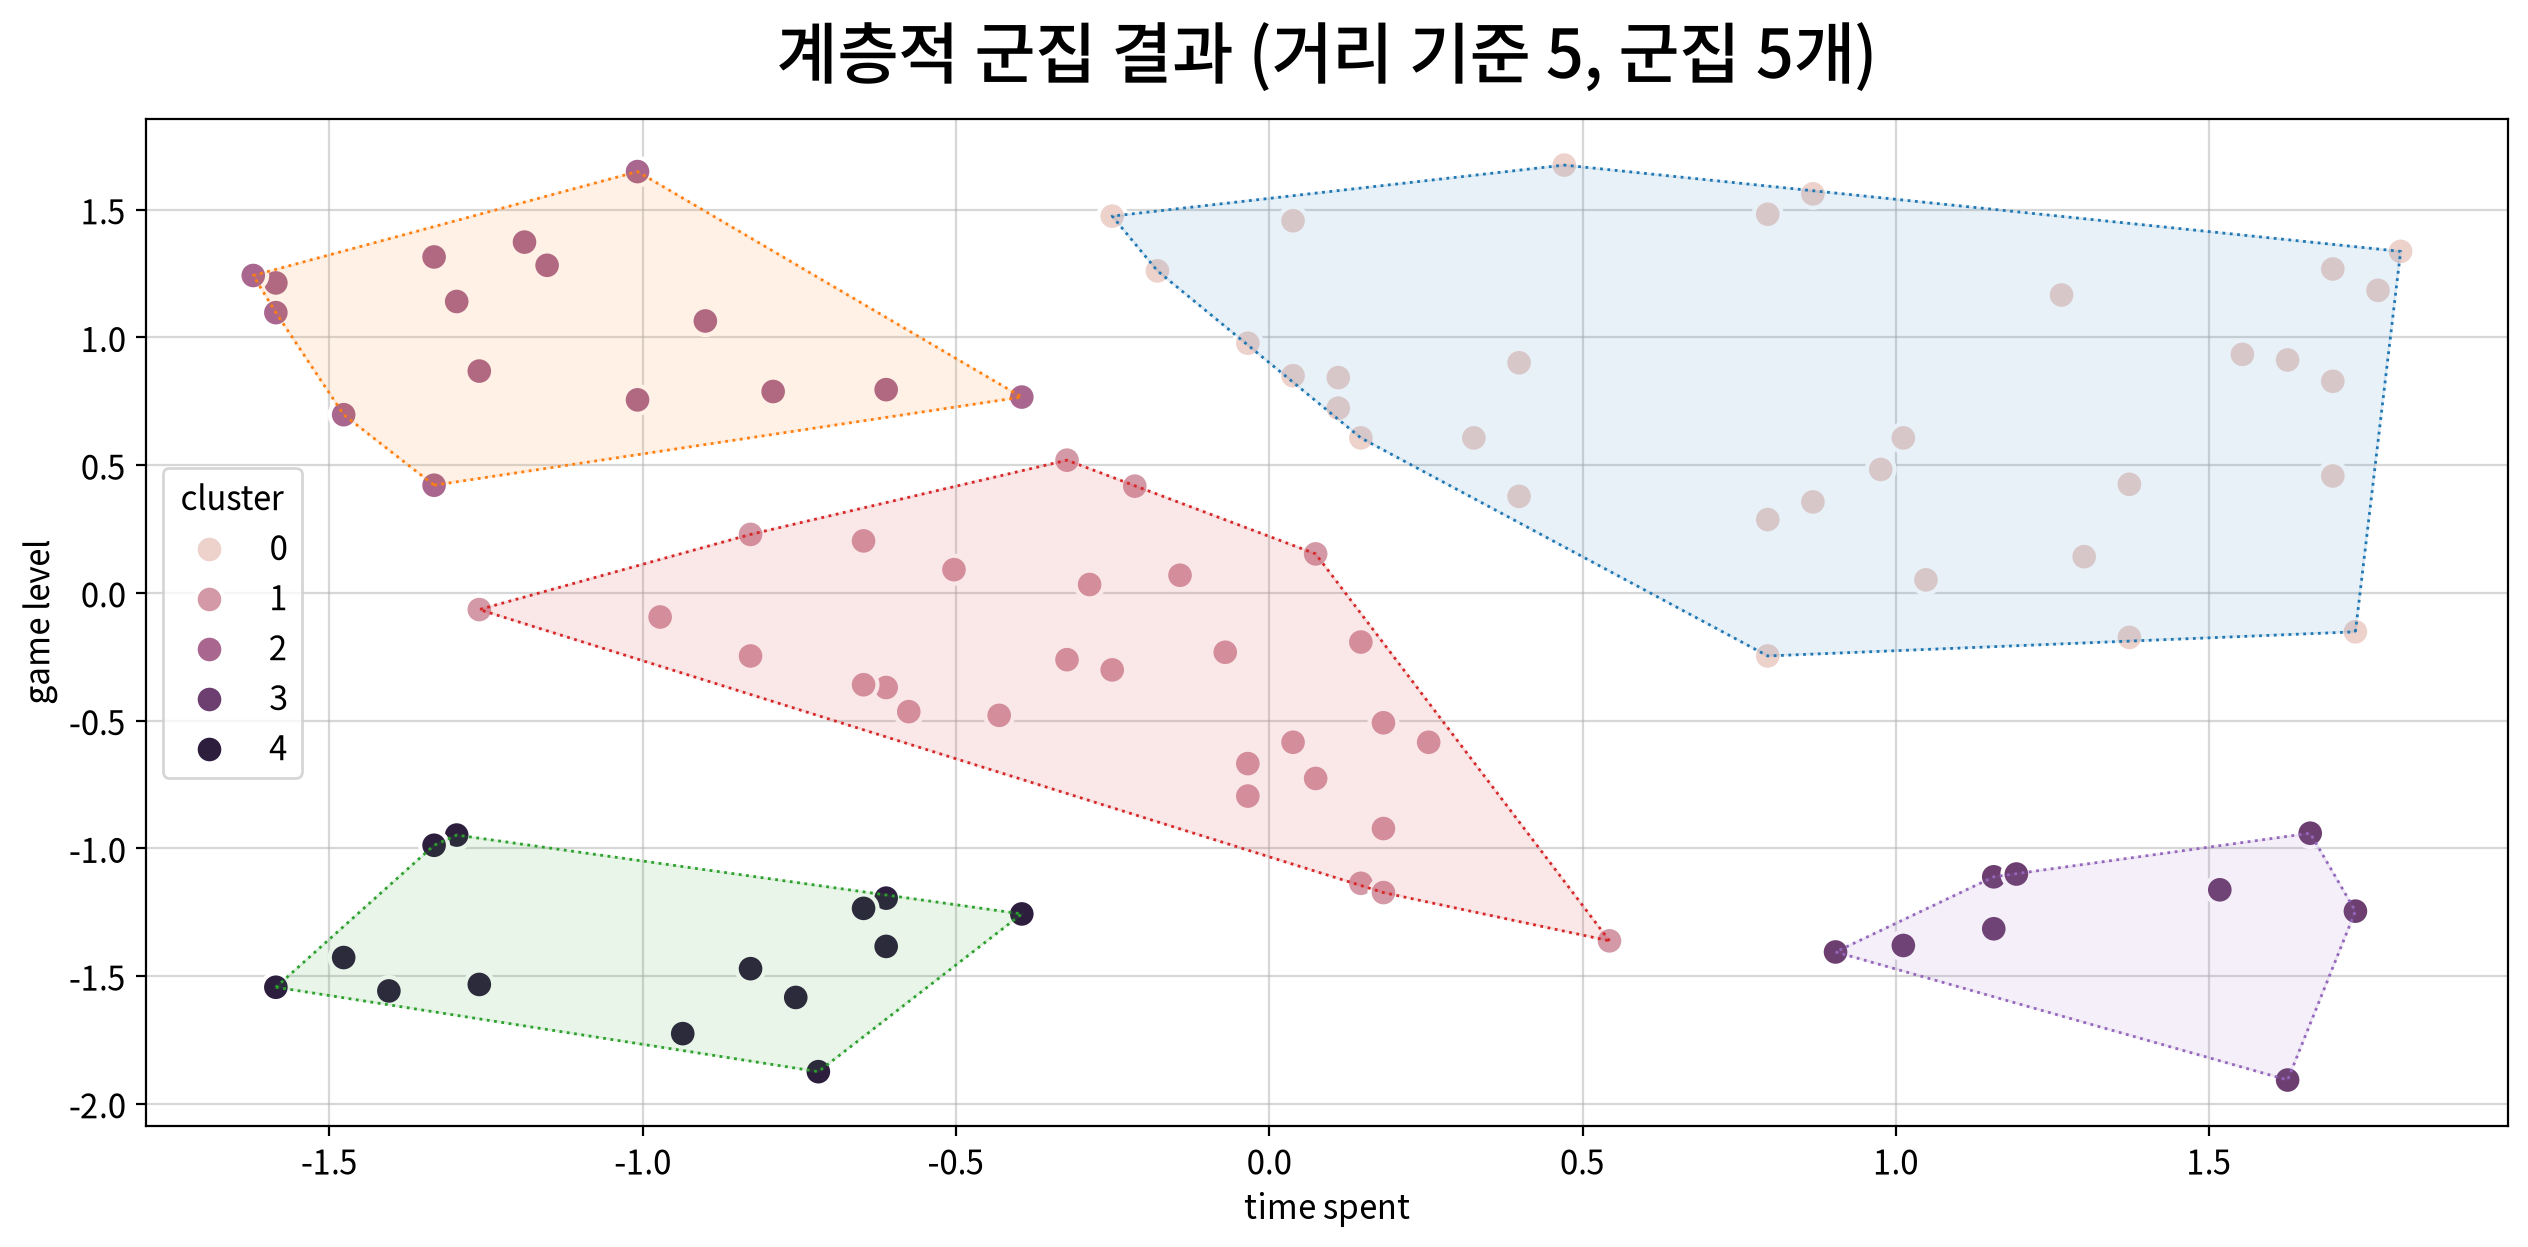

In [5]:
my_plot.scatterplot(data=result_df, x="time spent", y="game level", hue="cluster",
    outline=True,
    title=f"계층적 군집 결과 (거리 기준 5, 군집 {estimator.n_clusters_}개)")

**분석 설정과 결과**
- 데이터: game_usage, 100행 · 변수 2개 (time spent, game level)
- `distance_threshold = 5`
- `linkage = 'ward'`
- → 군집 5개

**군집별 인원**
- 군집 0: 32명
- 군집 1: 29명
- 군집 2: 16명
- 군집 3: 9명
- 군집 4: 14명

## 3. 실루엣 지수로 결과 확인



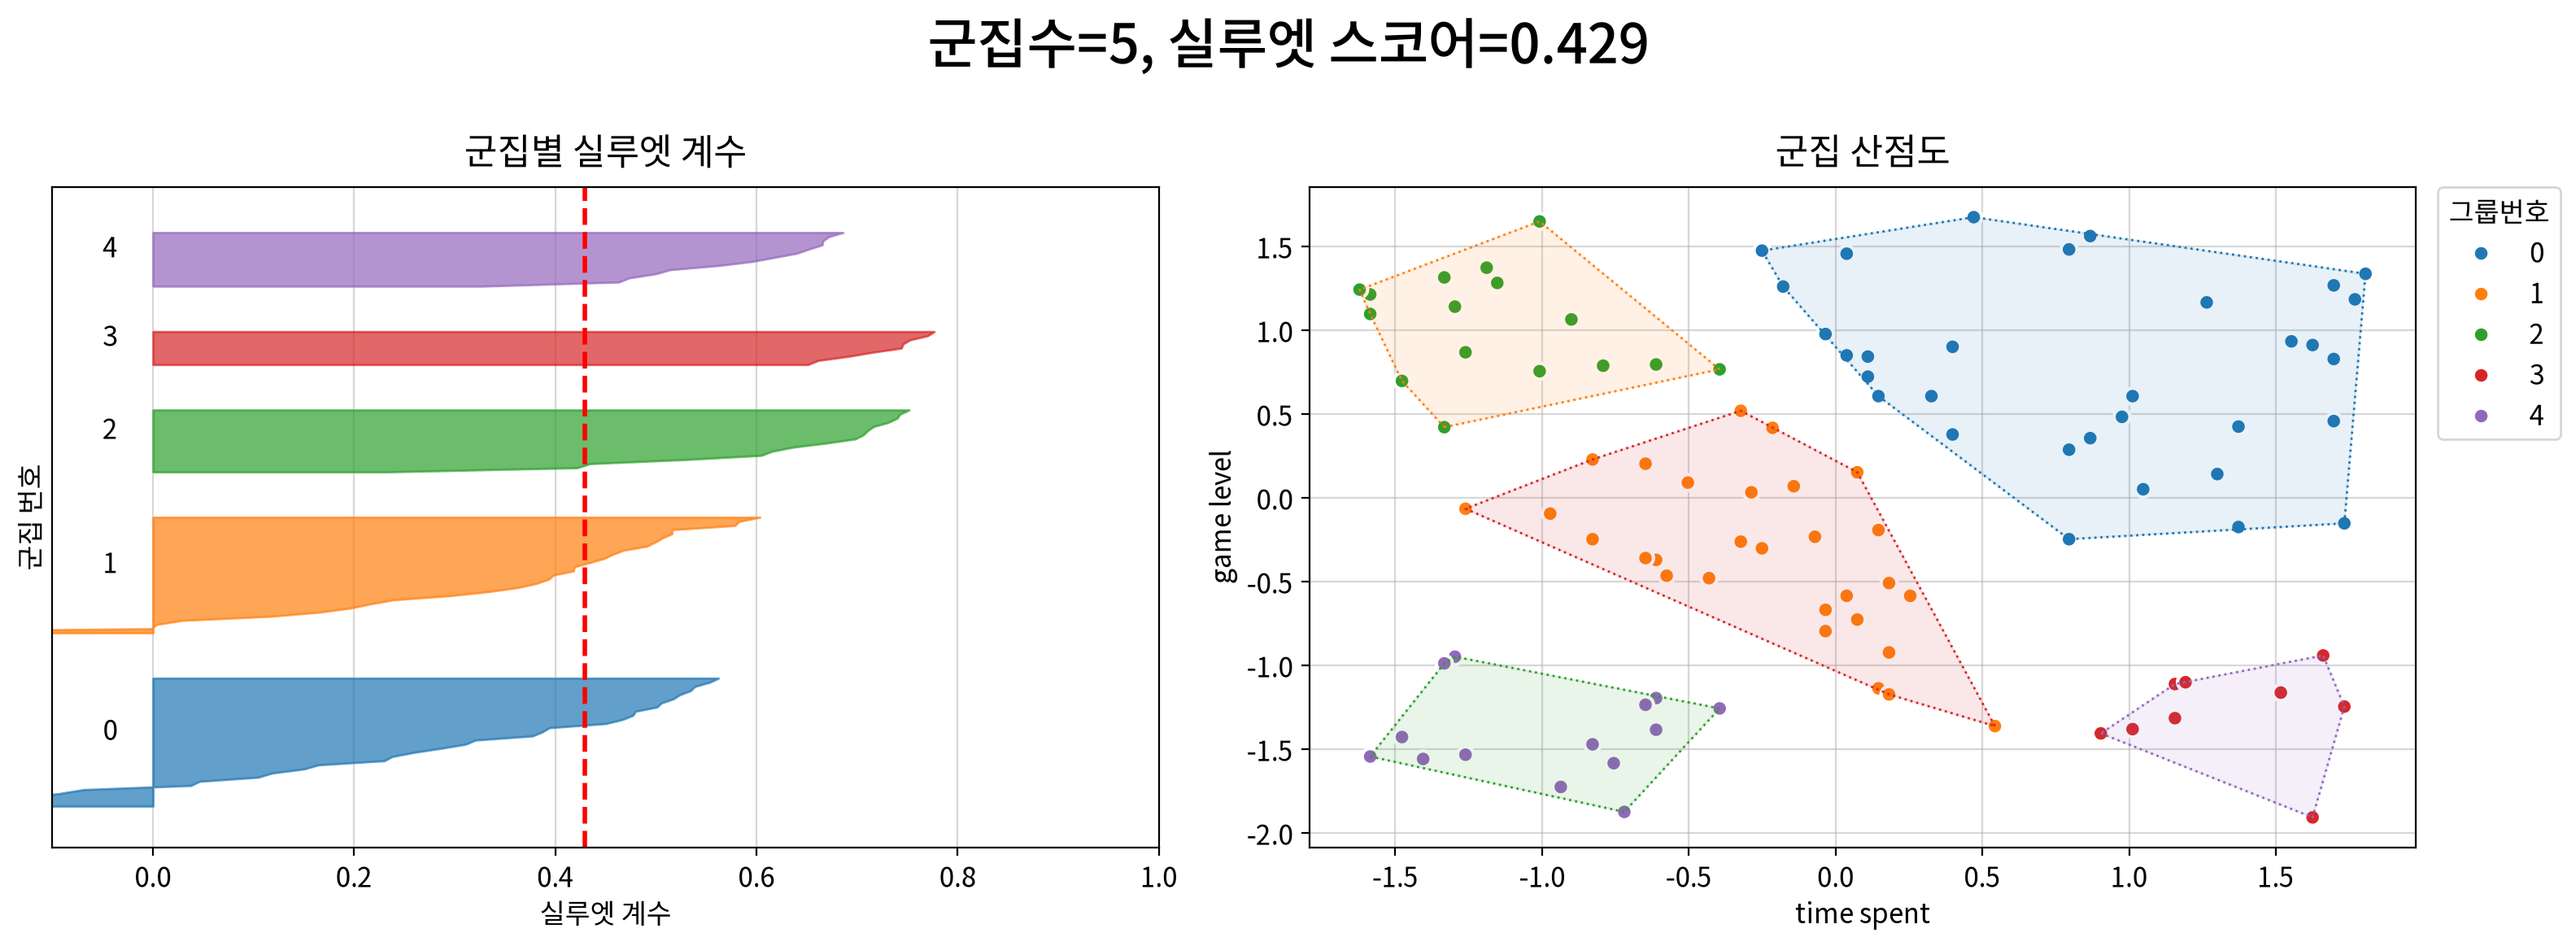

In [6]:
my_cluster.visualize_silhouette(estimator=estimator, data=sdf)


**결과**: 군집수=5, 실루엣 스코어=0.429
기준치(0.5 이상이면 양호)에 못 미친다

### 실루엣 점수가 낮아도 그림이 납득되면 쓸 수 있다

실루엣은 동글동글한 그룹을 전제로 만든 지표라, 모양이 복잡한 군집에는 잘 맞지 않는다.

**"지표가 낮다 = 나쁘다"가 아니라 "지표가 이 상황에 안 맞는다"일 수 있다**
→ 점수만 믿지 말고 그림을 함께 보고 분석가가 판단한다

---

# 덴드로그램 읽는 법

| 세로축 (Y) | 가로축 (X) | 가로선으로 자르기 |
|---|---|---|
| 합쳐질 때의 거리 → 높을수록 억지로 합쳐진 것 | 개별 데이터 (또는 이미 묶인 그룹) | 자른 높이에서 세로선이 몇 개 지나가는지 = 군집 수 |

> 가지가 길게 뻗은 곳에서 자른다 — 억지로 합쳐지기 직전에 멈추는 것

**덴드로그램의 기본 모양** — 아래에서 위로 합쳐지며, 높이가 병합 거리다

## 덴드로그램 — 전체와 축약 비교

전체는 읽을 수 없다 — 그래서 축약해서 본다

- **전체 덴드로그램**: 가지가 빽빽해 눈금을 읽을 수 없다
- **축약 덴드로그램**: 마지막 30개 가지만 표시

**축약하면 보이는 것**
가지가 길게 뻗은 구간이 드러나 자를 높이를 눈으로 고를 수 있다

**축약의 대가**
아래쪽 세부 병합 과정은 괄호 숫자로 요약되어 개별 데이터는 보이지 않는다

## # 덴드로그램용 데이터 생성 코드 - dendrogram_source.txt를 my_cluster.py에 적용 

## #03. 덴드로그램 
### 1. 덴드로그램용 데이터 만들기 
sklearn에는 덴드로그램을 바로 그리는 기능이 없어서, 모델이 가진 정보를 조합해 주는 함수가 필요하다 

In [7]:
data = my_cluster.dendrogram_source(estimator)
data[:5]

array([[3.60000000e+01, 8.70000000e+01, 3.76869846e-02, 2.00000000e+00],
       [5.10000000e+01, 9.80000000e+01, 3.76869846e-02, 2.00000000e+00],
       [2.50000000e+01, 4.20000000e+01, 4.63269855e-02, 2.00000000e+00],
       [8.00000000e+00, 3.70000000e+01, 5.11987456e-02, 2.00000000e+00],
       [1.20000000e+01, 1.70000000e+01, 5.38374037e-02, 2.00000000e+00]])

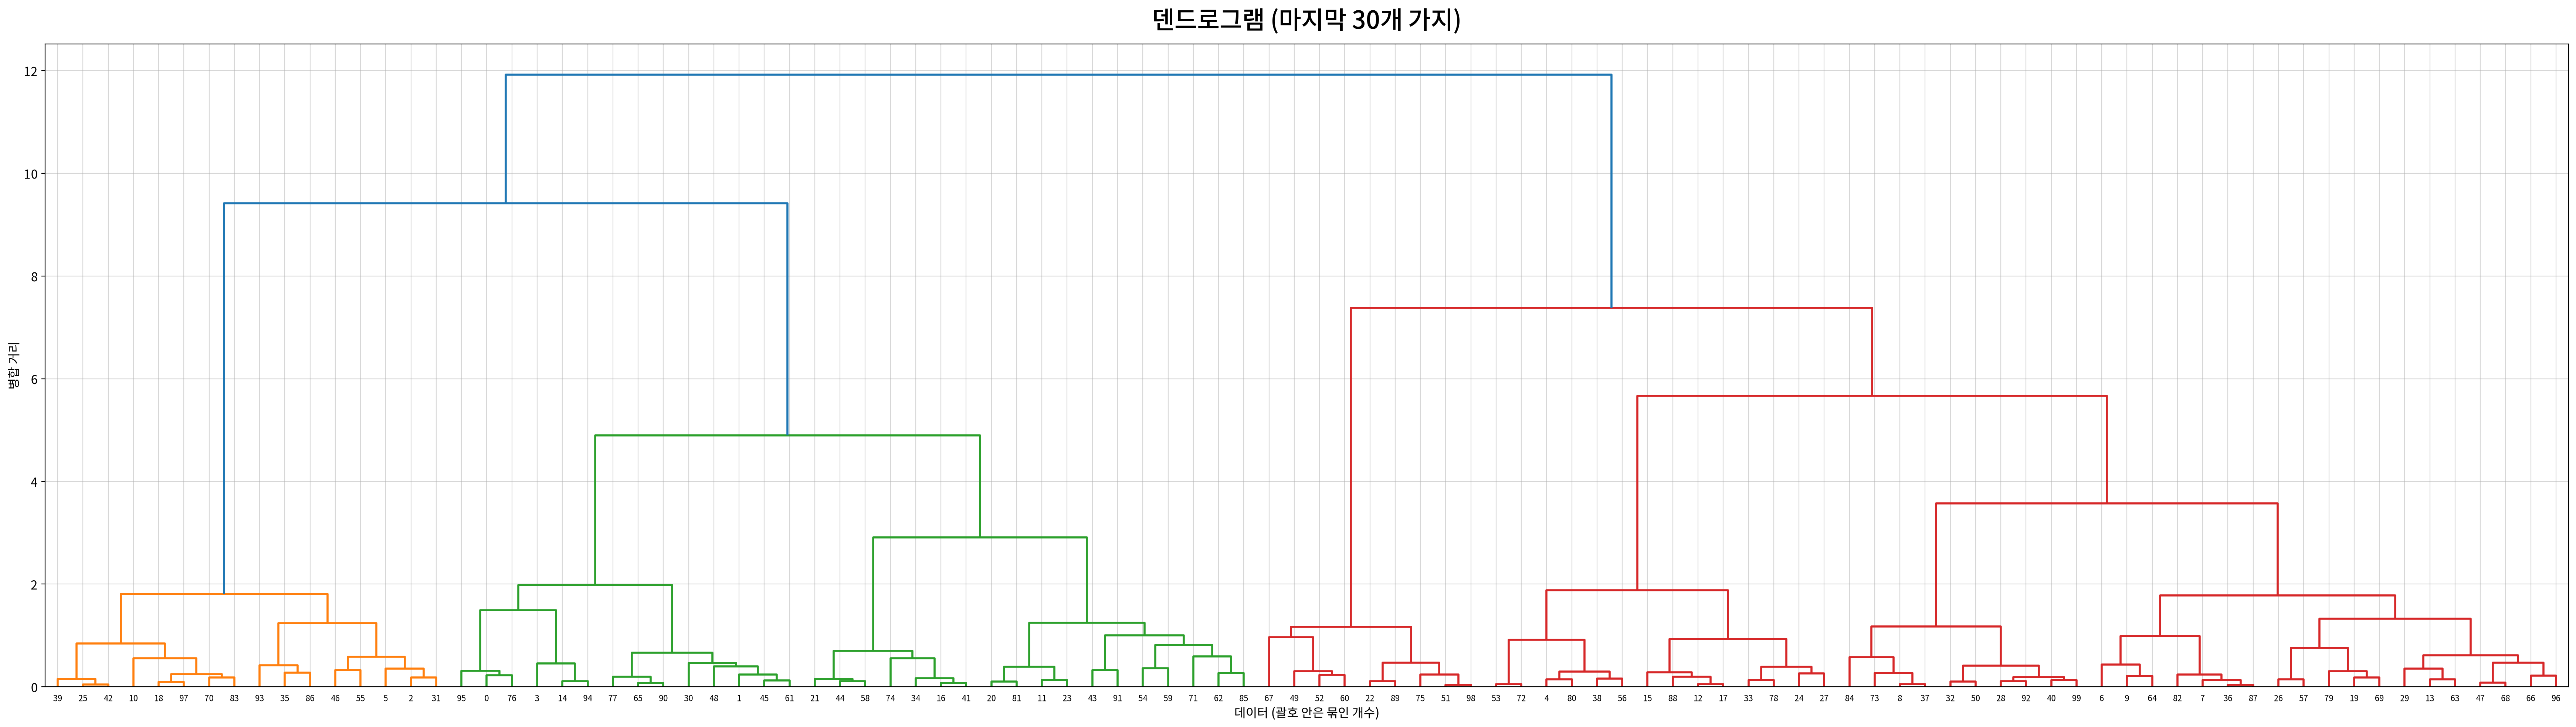

In [8]:
fig, ax = my_plot.init(width=3500, height=1000, title="덴드로그램 (마지막 30개 가지)")

dendrogram(
    data,
    ax=ax,
    p=30,
    truncate_mode=None,
    leaf_rotation=0,
    leaf_font_size=8,
    count_sort="ascending",
)

ax.set_xlabel("데이터 (괄호 안은 묶인 개수)")
ax.set_ylabel("병합 거리")

my_plot.show()

## # 05. 모듈화 기능 확인 
### 1. 덴드로그램 시각화 

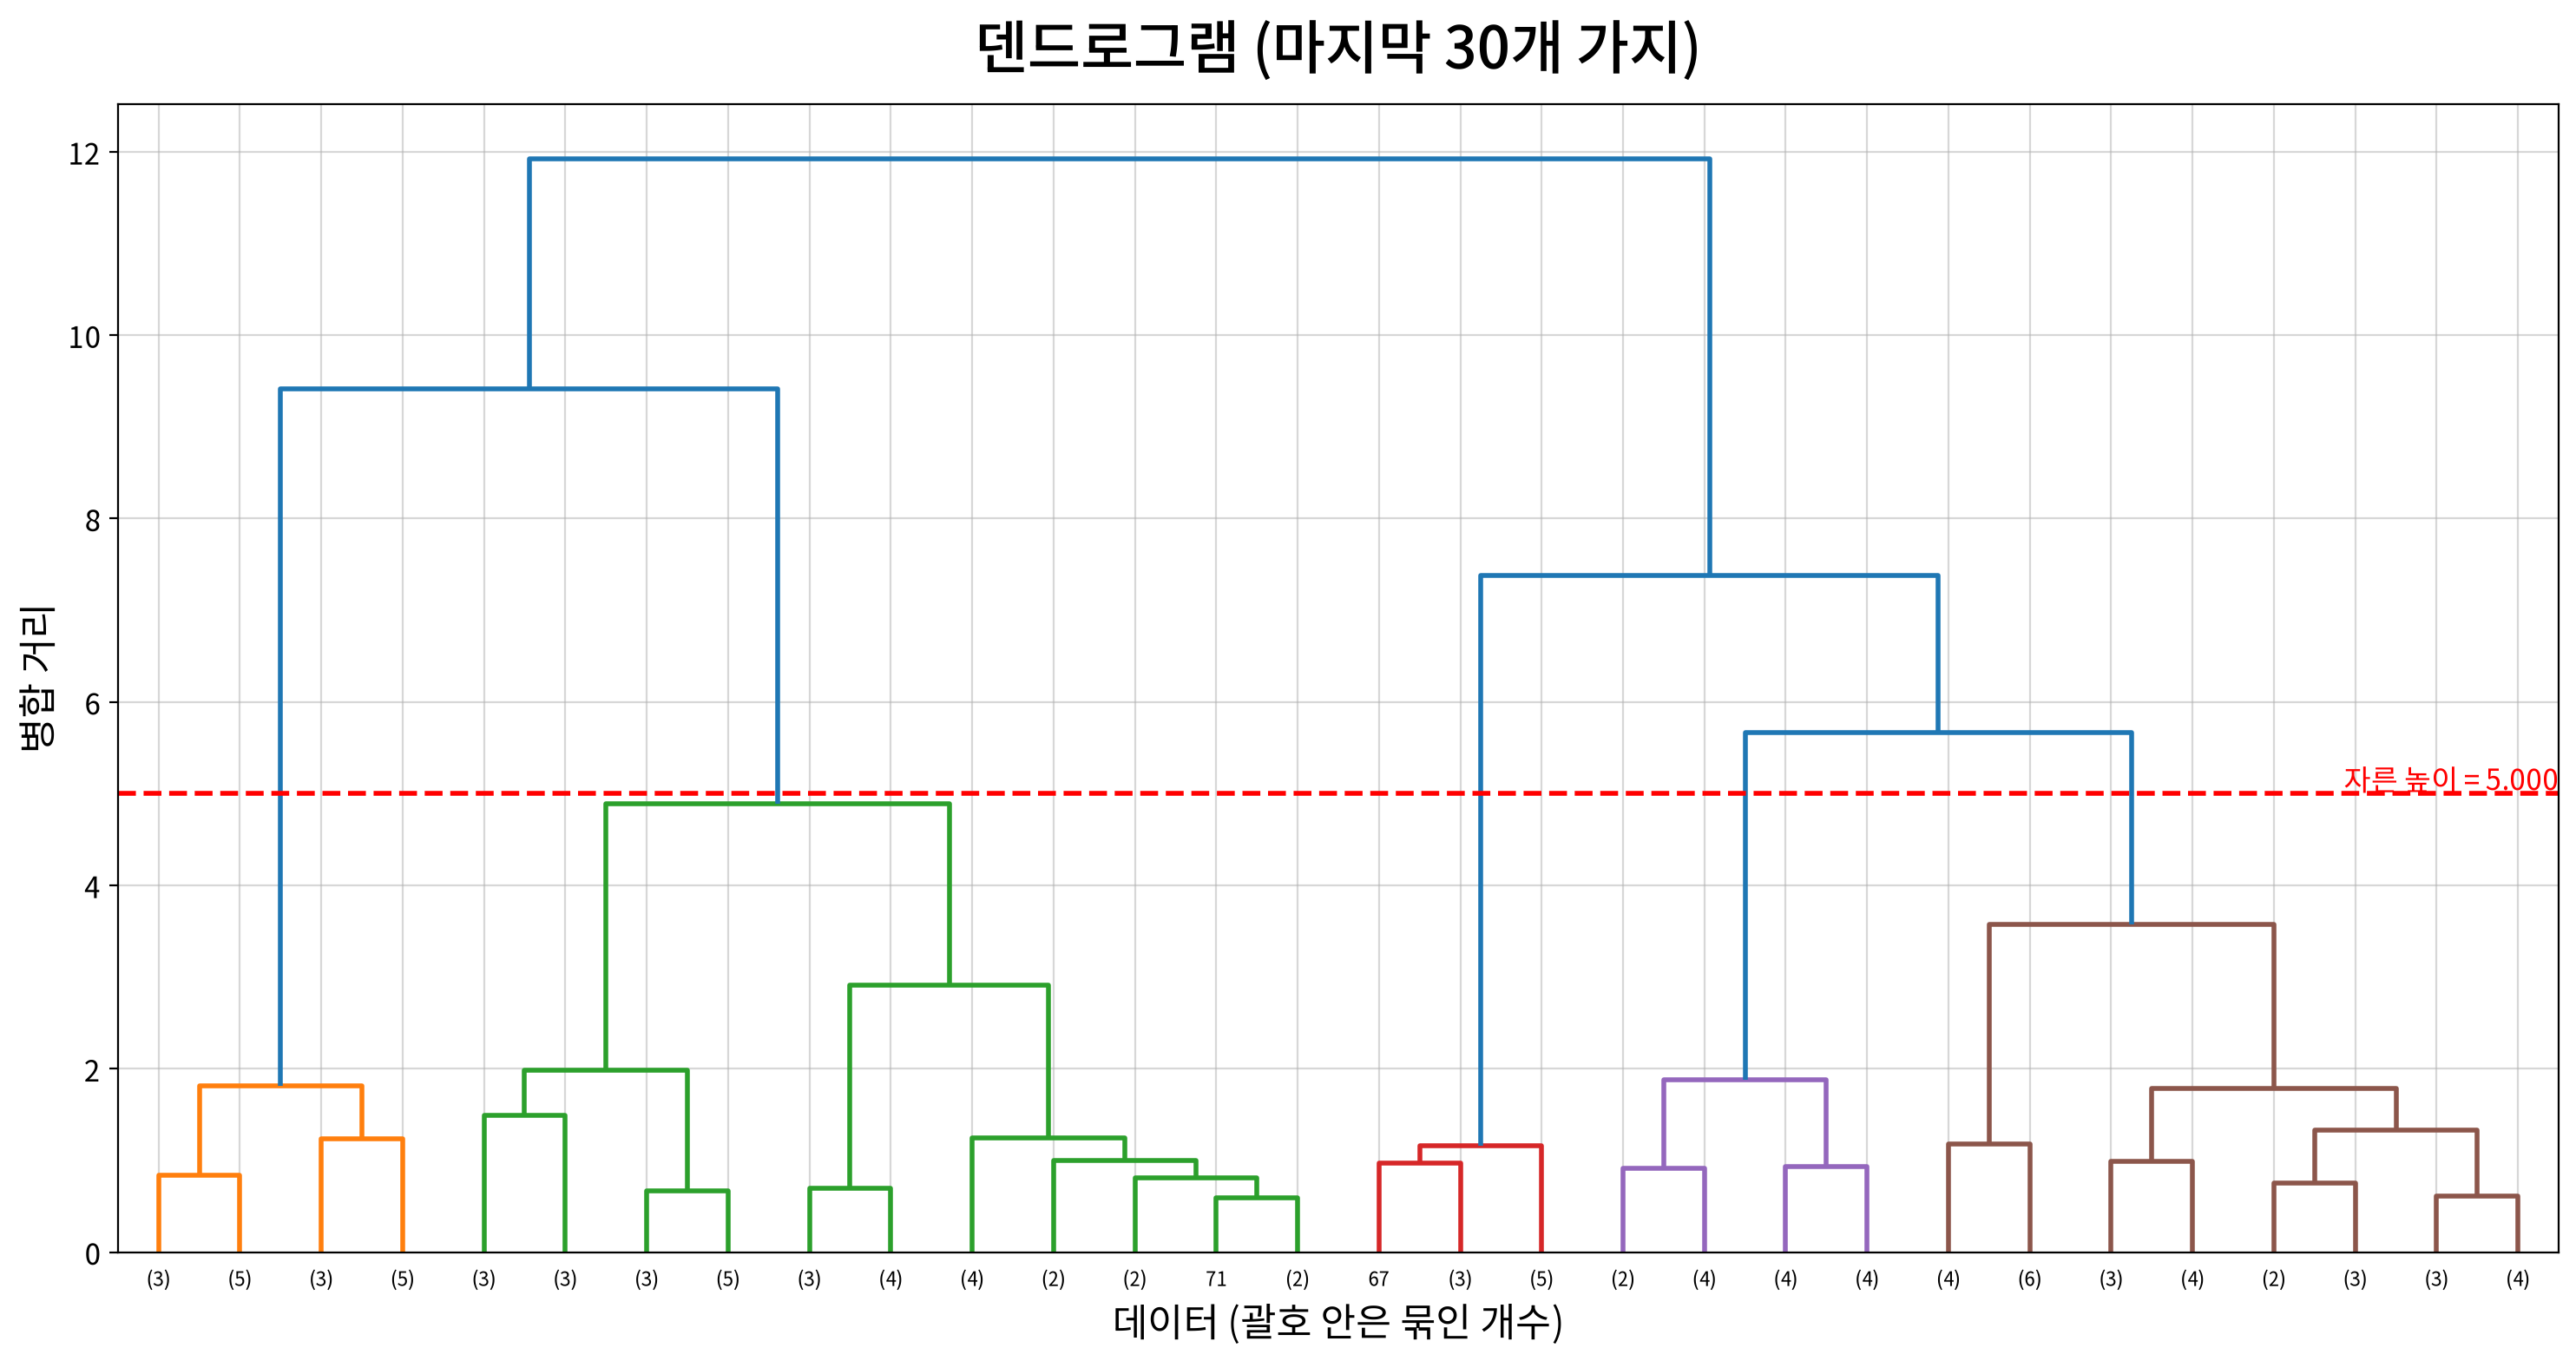

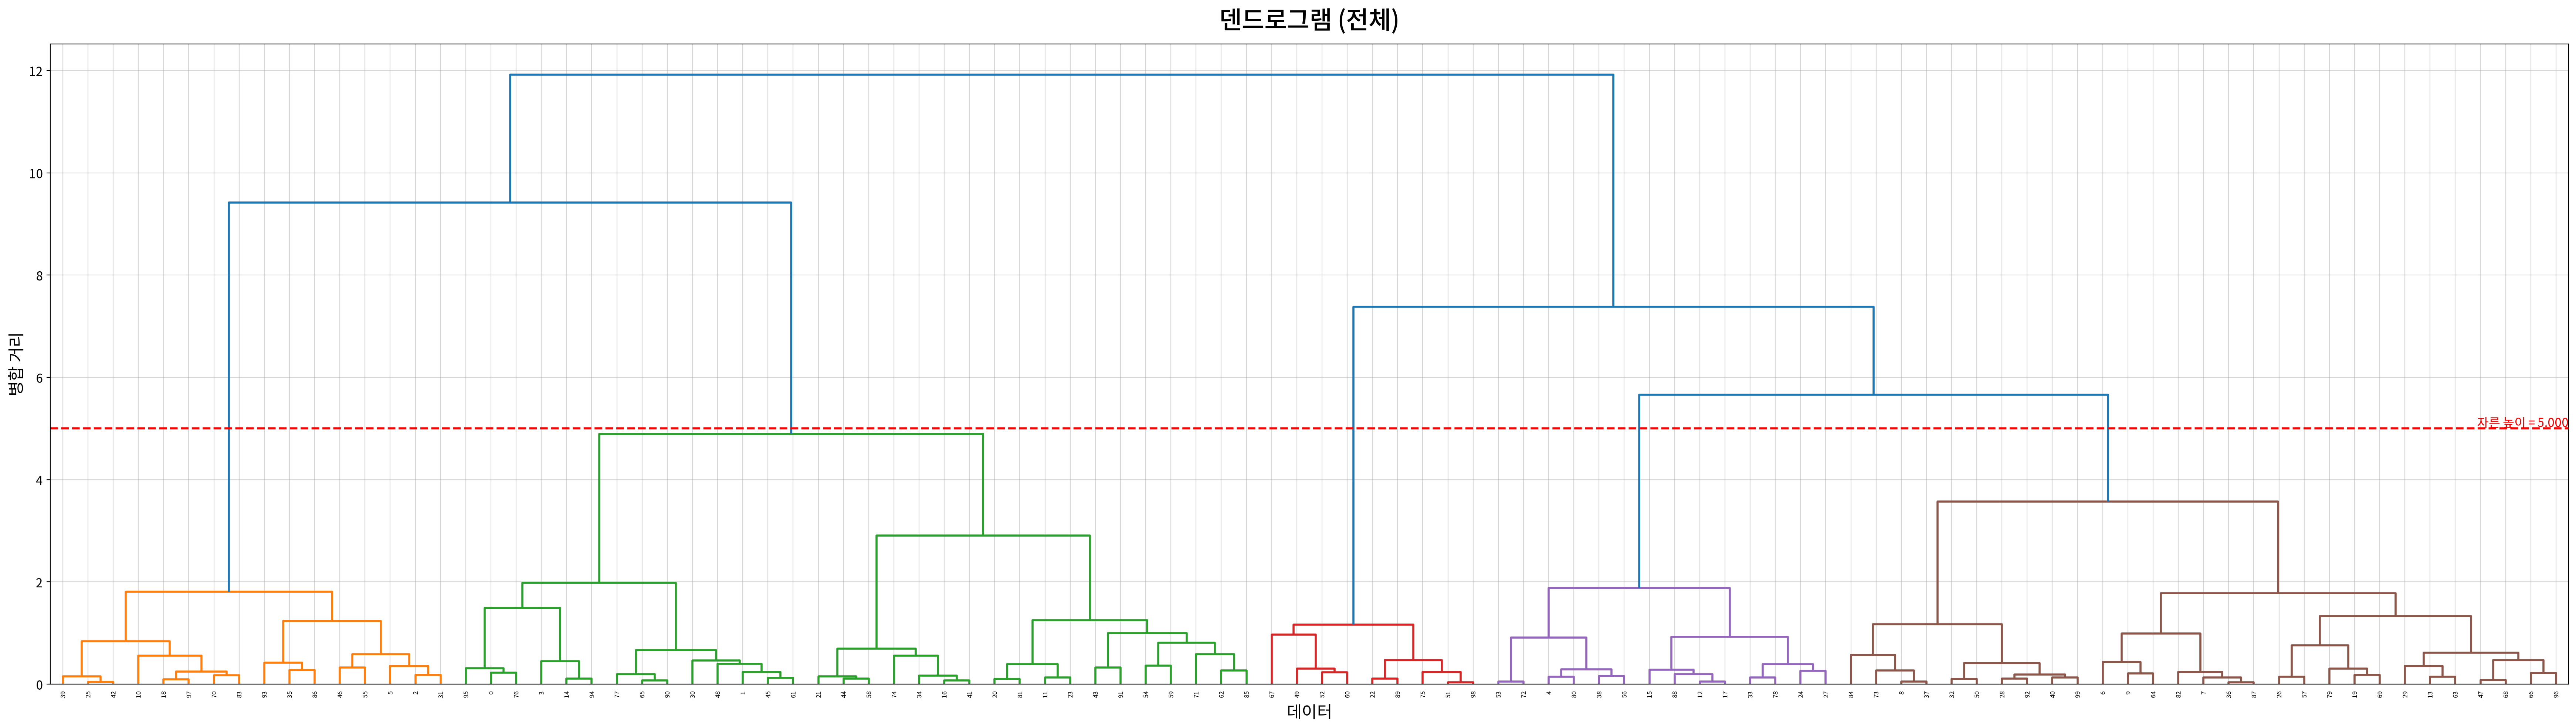

In [9]:
# #03에서 한 일(linkage 행렬 만들기 -> 캔버스 생성 -> 그리기 -> 축 이름 지정)을 
# 모듈화 함수 하나가 대신한다 
my_cluster.plot_dendrogram(estimator, title="덴드로그램 (마지막 30개 가지)",
                           width=1500, height=800)

# 전체를 보고 싶다면 가지를 생략하지 않도록 truncate_mode를 None으로 지정한다 
my_cluster.plot_dendrogram(estimator, truncate_mode=None, 
                           leaf_rotation=90, leaf_font_size=6,
                           title="덴드로그램 (전체)", width=3500, height=1000)

### 2. 거리 기준으로 자동 결정 ( #02와 같은 조건 )


StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00            -1.62~1.81
game level        13.00 ~ 999.00            -1.91~1.67
[계층적 군집]군집 수 = 5, 연결 방법 = ward, 거리 = euclidean
  . 자른 높이(병합거리) = 5.0000
   . 군집별 데이터 개수: 0번 32개, 1번 29개, 2번 16개, 3번 9개, 4번 14개


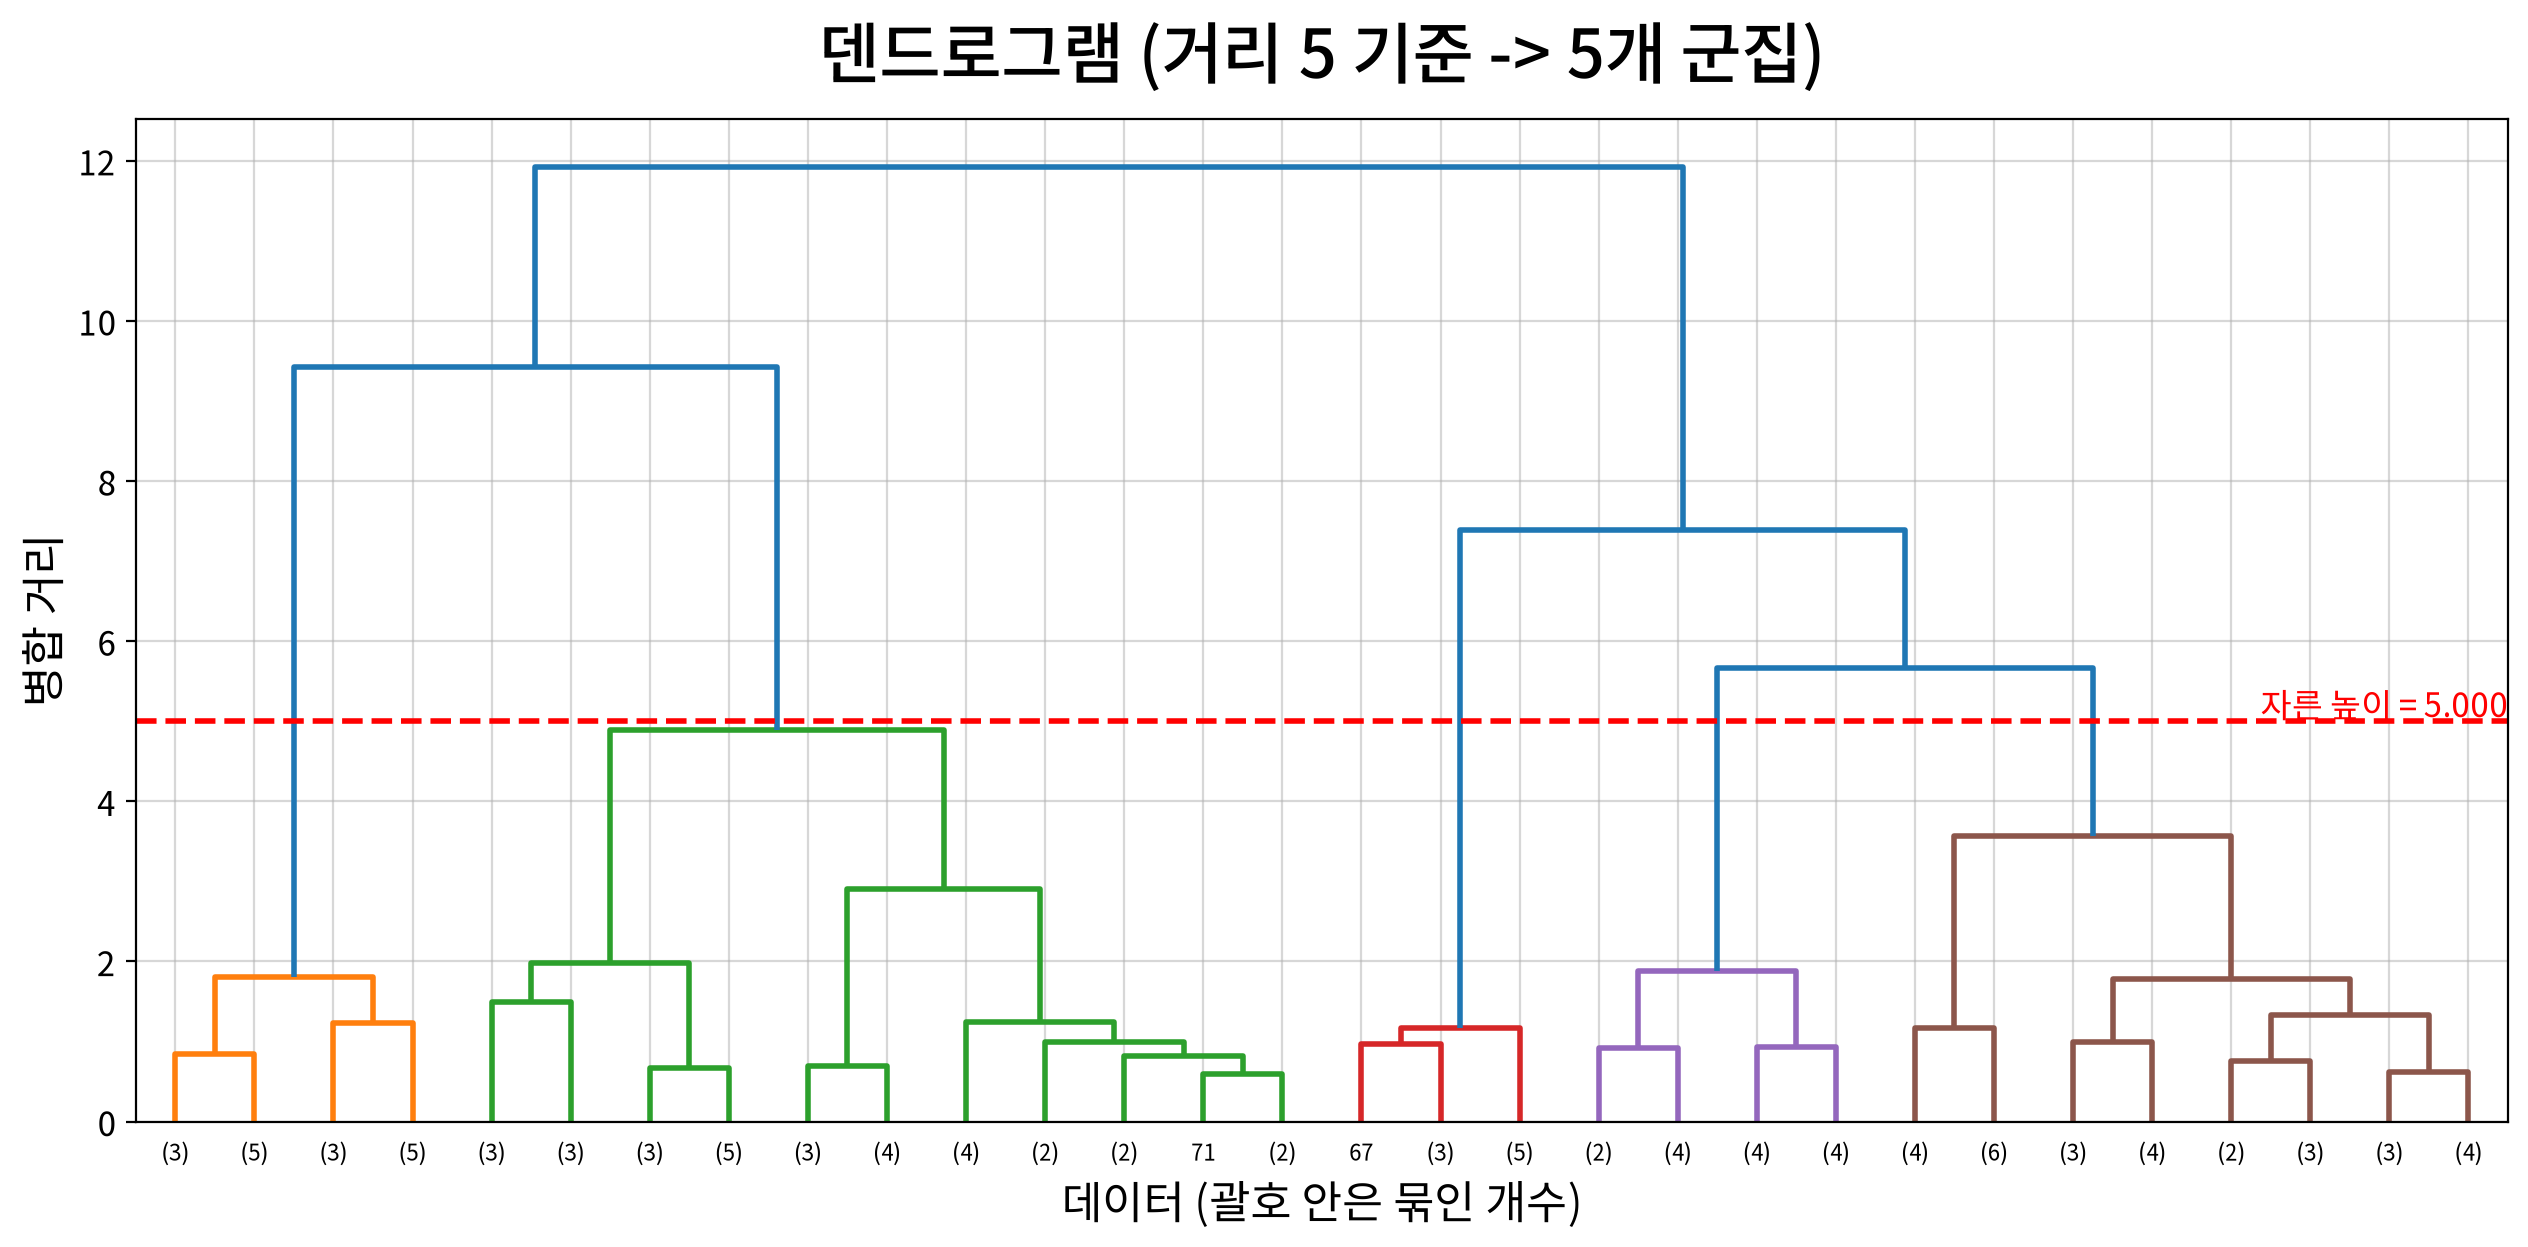

,time spent,game level,그룹번호
0,-0.251,1.475,0
1,0.326,0.607,0
2,-0.612,0.795,2
3,0.471,1.675,0
4,-1.405,-1.559,4


In [10]:
# 스케일링(기본값 standard)까지 함수가 알아서 수행한다 
estimator, df = my_cluster.agglomerative(origin, distance_threshold=5)
df.head()

덴드로그램의 빨간 점선이 **자른 높이(거리5)** 다.\
이 선과 만나는 가지의 수가 곧 군집 수가 된다. 

### 3. 군집 수를 직접 지정 

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00            -1.62~1.81
game level        13.00 ~ 999.00            -1.91~1.67
[계층적 군집]군집 수 = 4, 연결 방법 = ward, 거리 = euclidean
  . 자른 높이(병합거리) = 6.5230
   . 군집별 데이터 개수: 0번 43개, 1번 32개, 2번 16개, 3번 9개


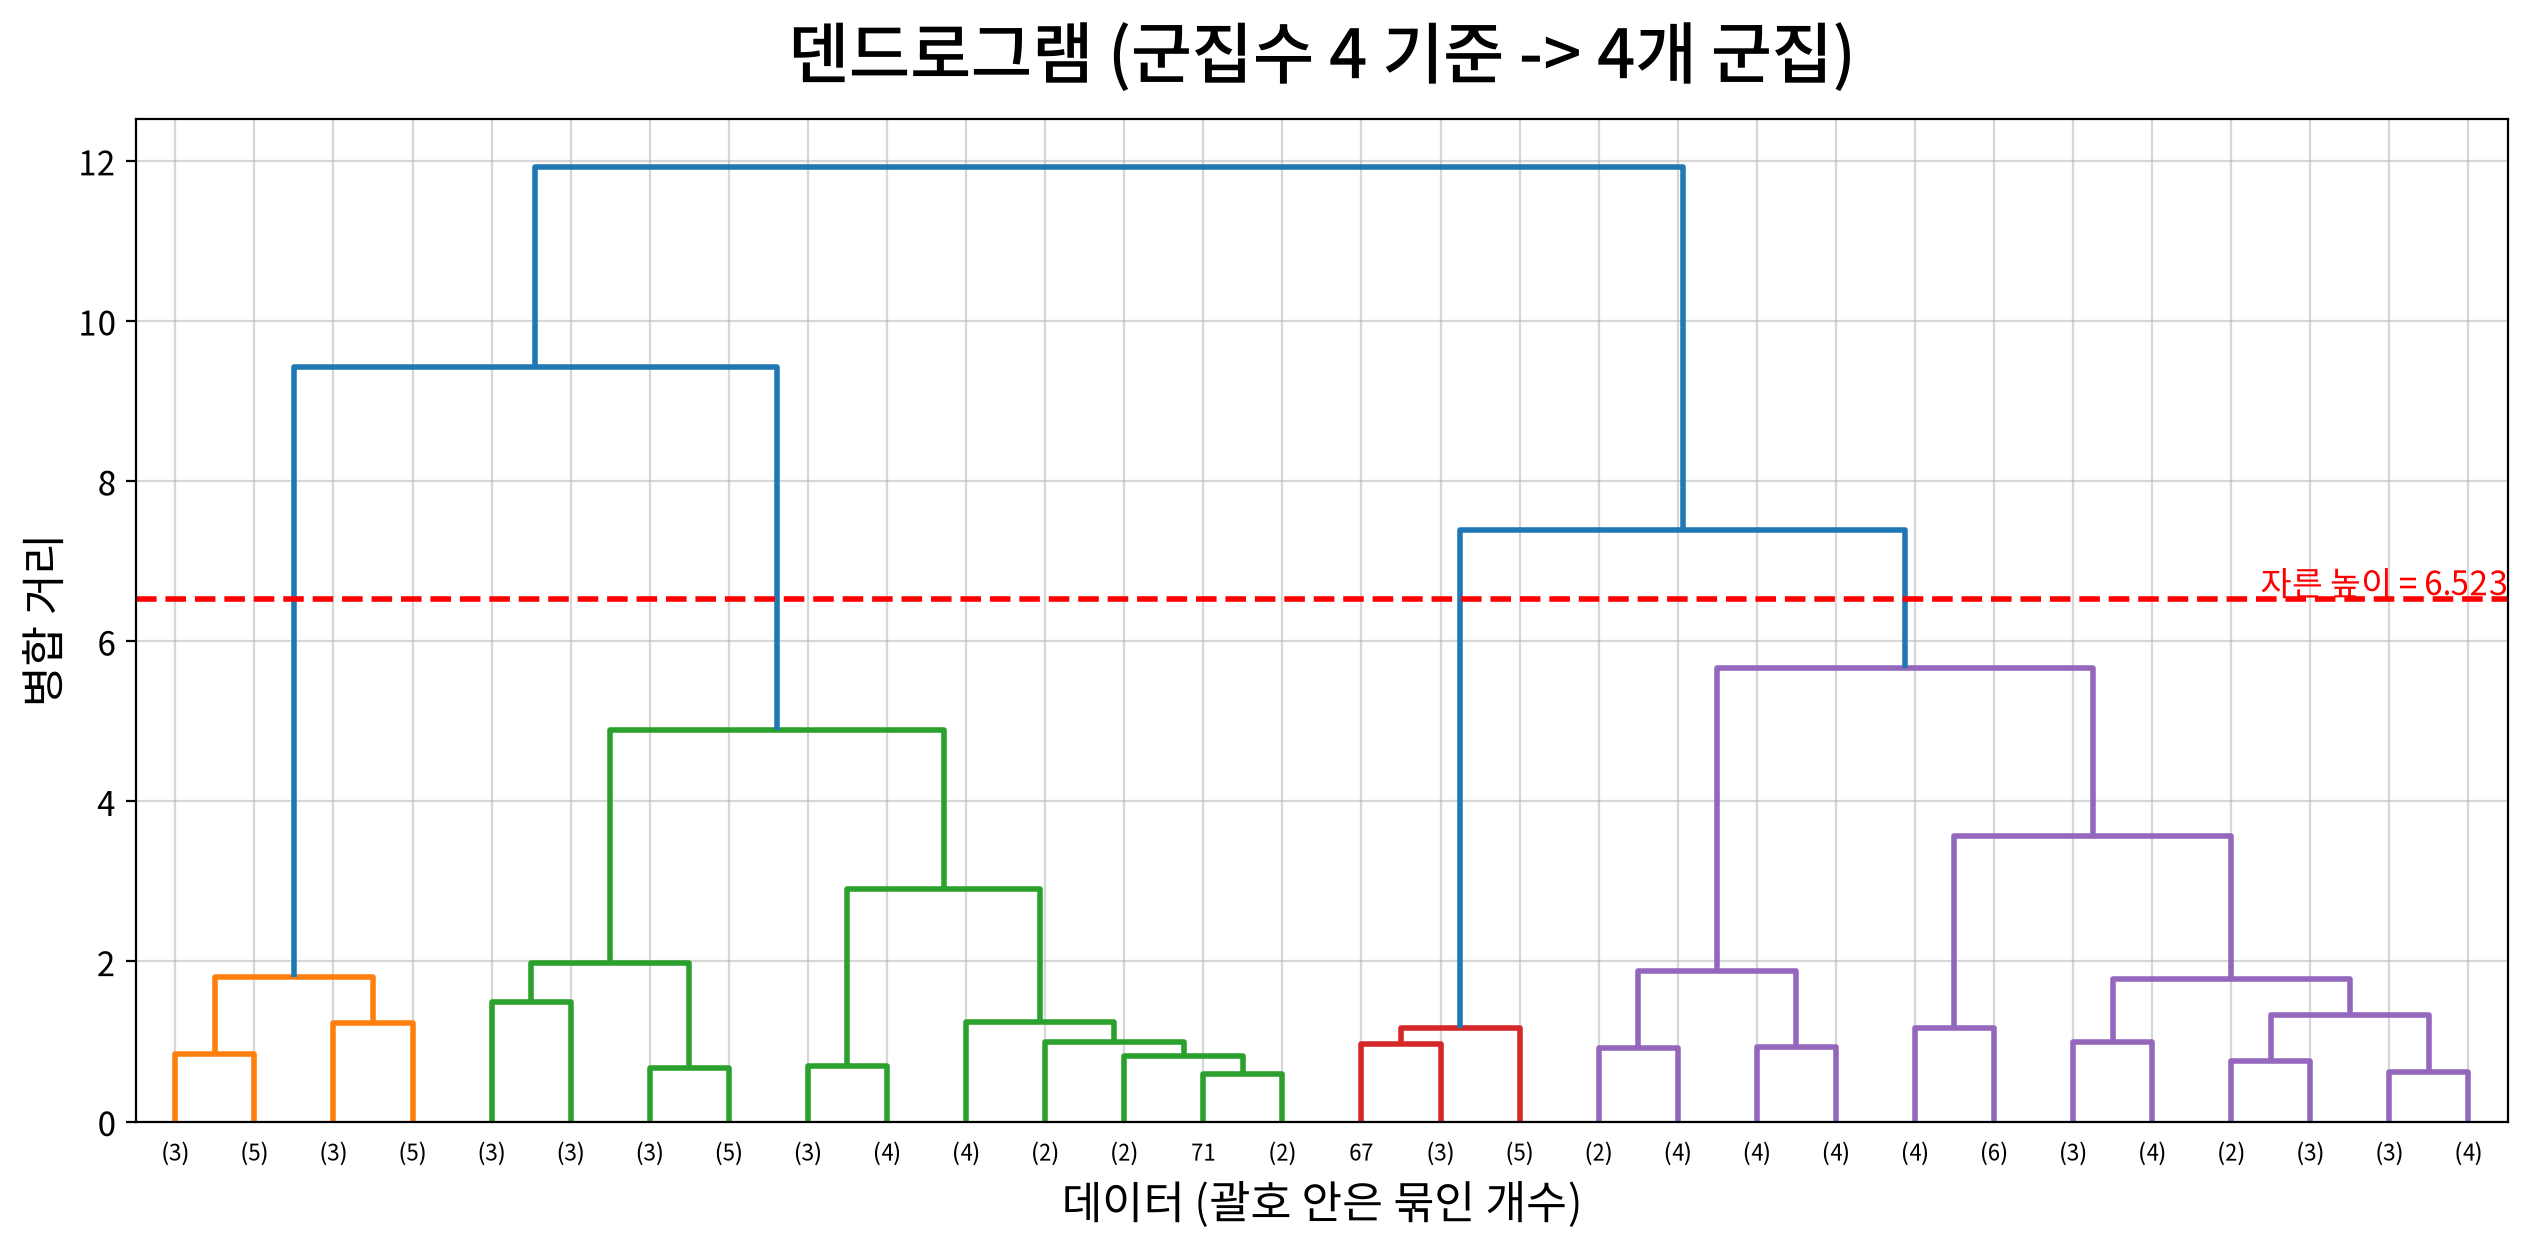

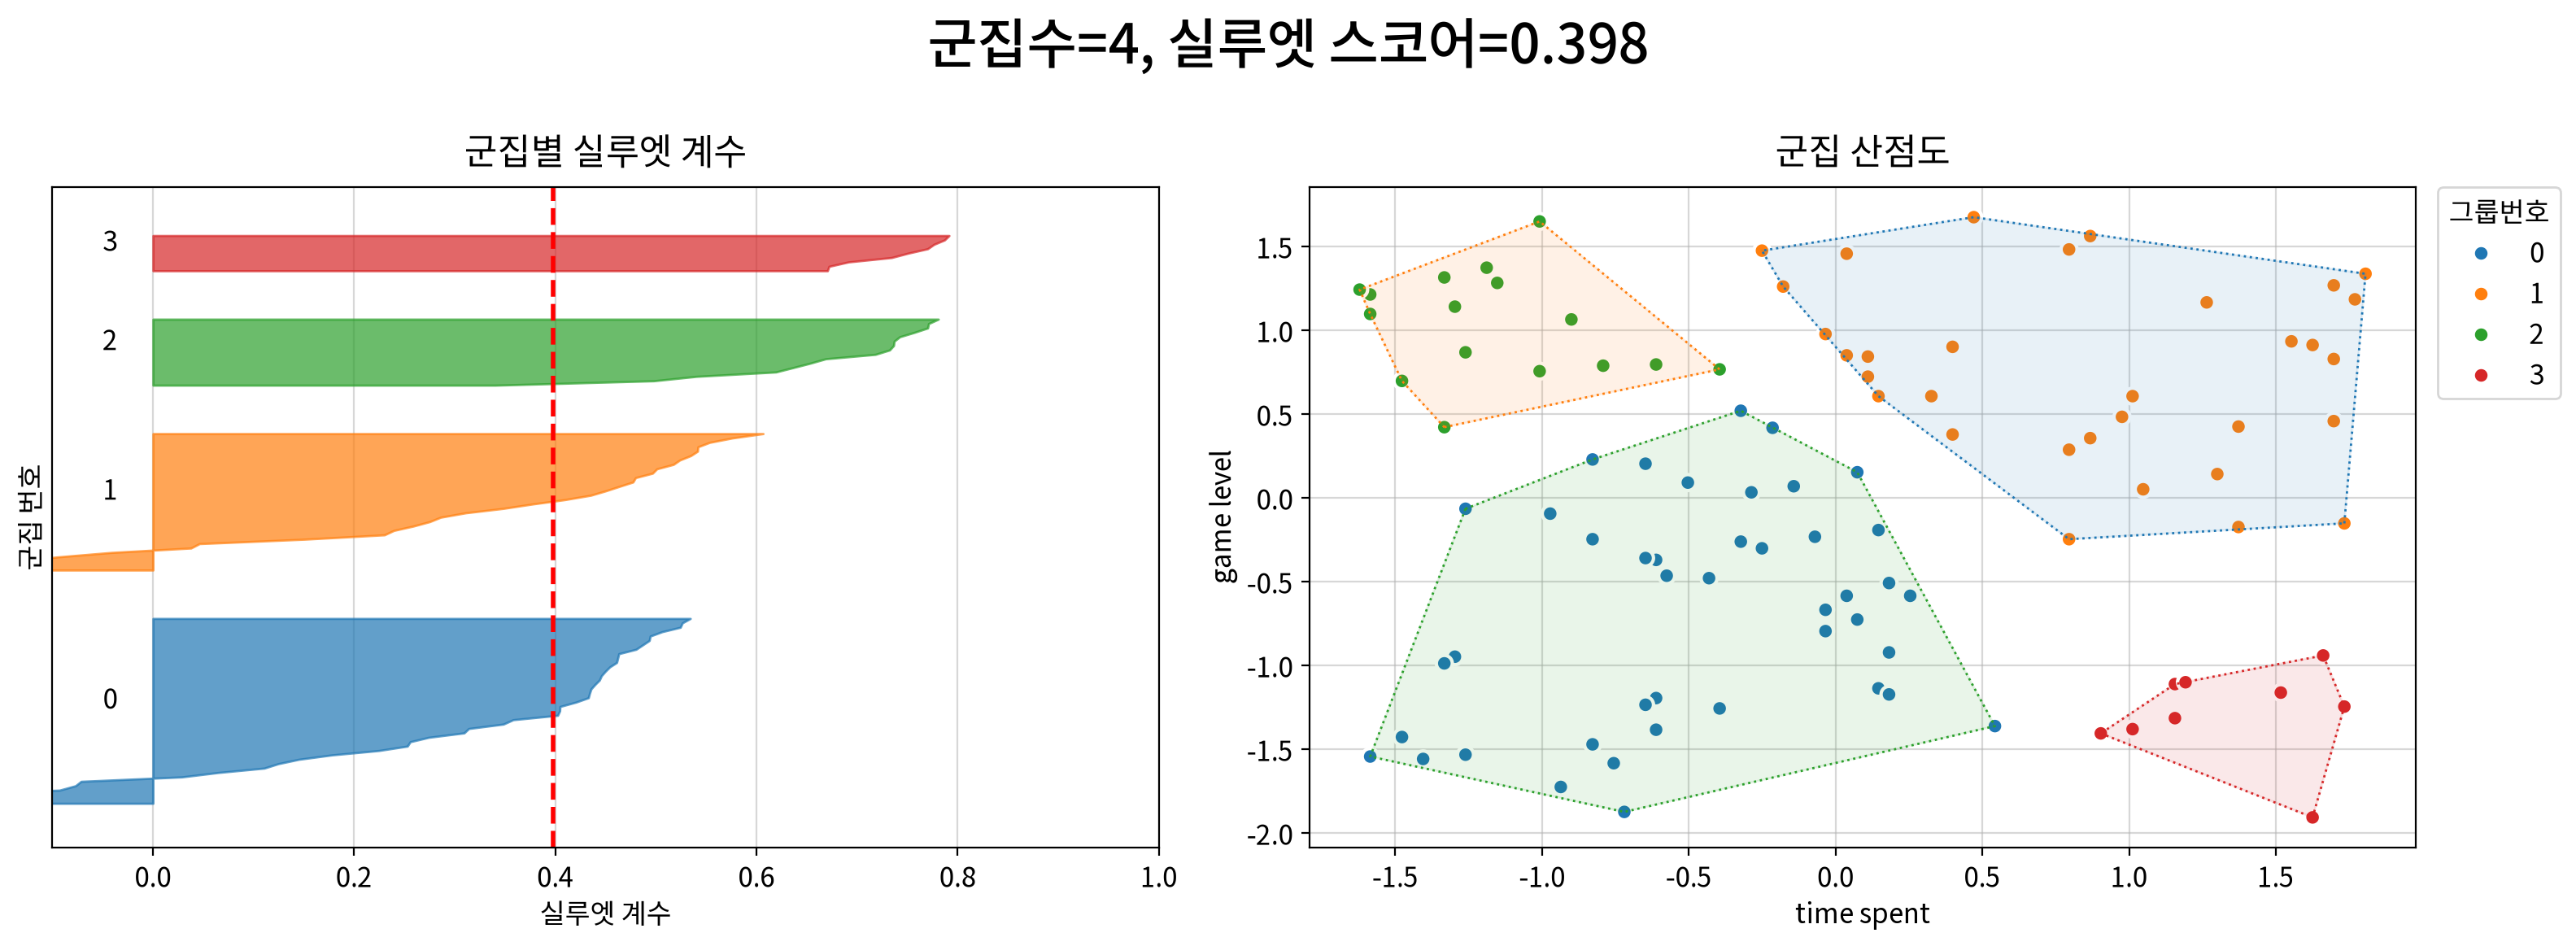

In [11]:
estimator, df = my_cluster.agglomerative(origin, k=4)

# 실루엣 지수도 함께 확인 (군집번호 컬럼은 함수가 알아서 제외한다)
my_cluster.visualize_silhouette(estimator=estimator, data=df)

### 3. 연결 방법 변경 + 덴드로그램 전체 표시 

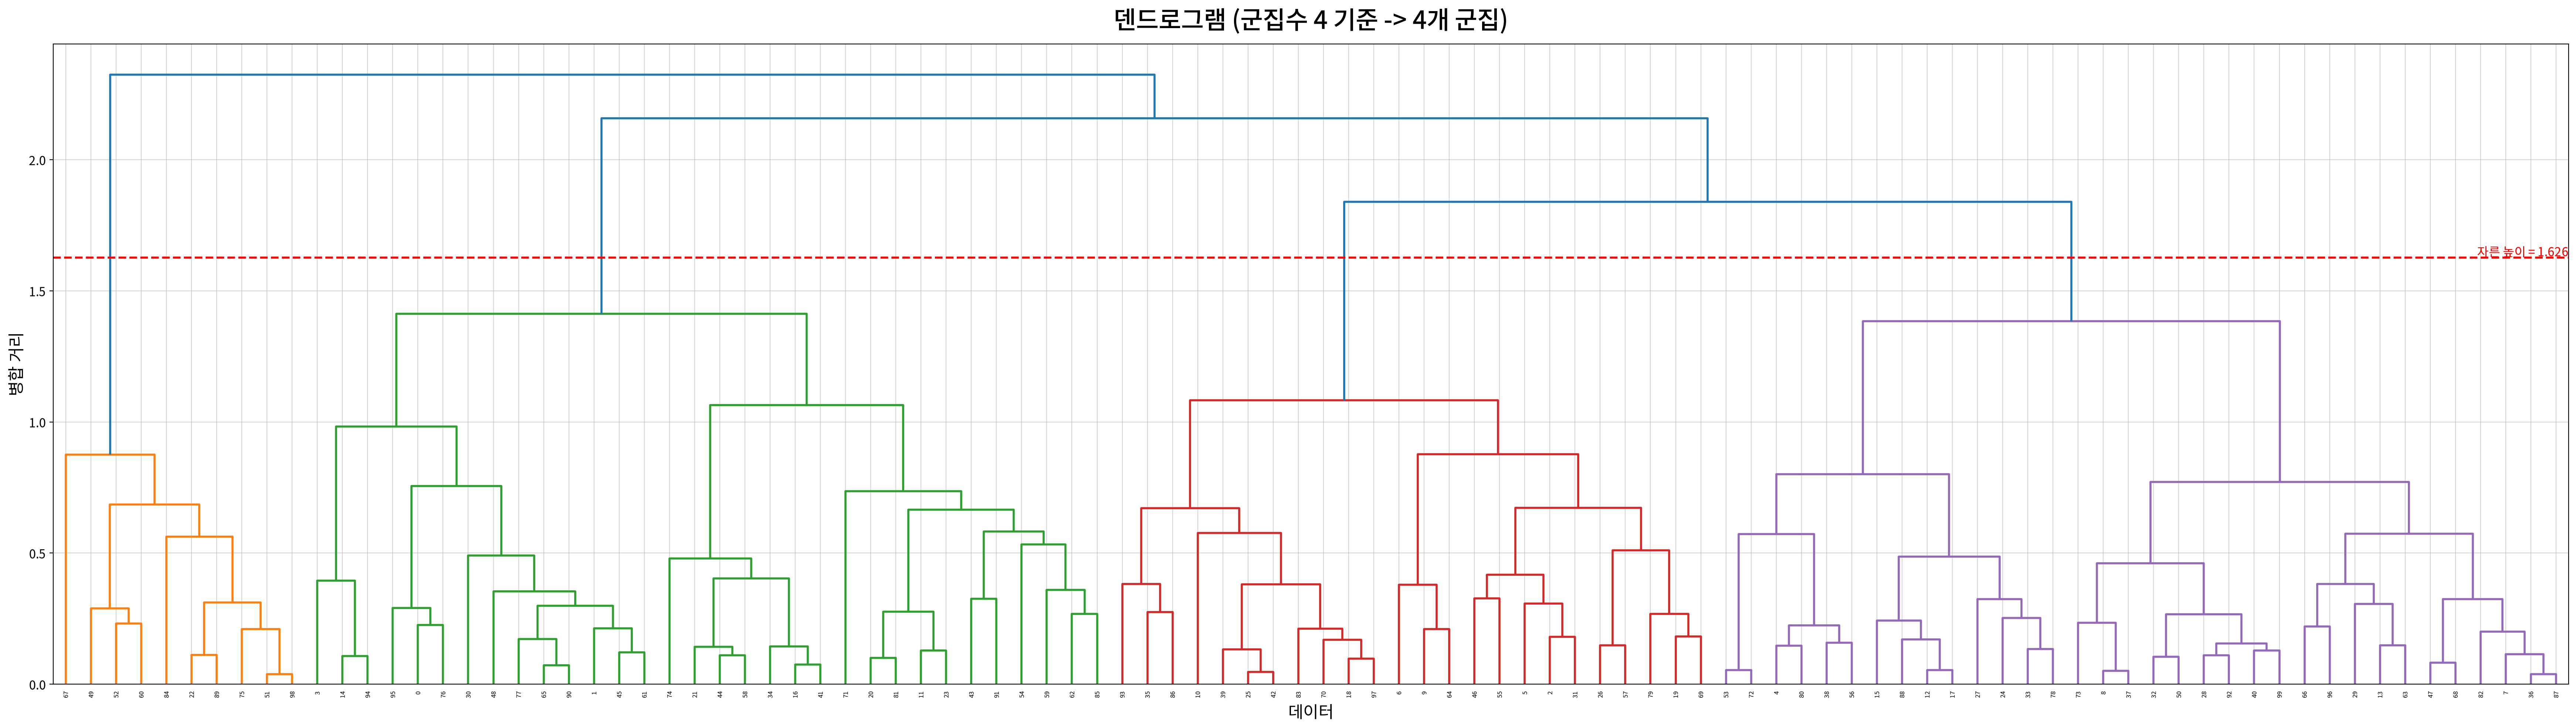

In [12]:
estimator, df = my_cluster.agglomerative(origin, k=4, 
                                         linkage="average", # 두 덩어리의 모든 쌍의 평균 거리로 합친다
                                         truncate_mode=None, # 가지를 생략하지 않고 전체를 표시 
                                         leaf_rotation=90, leaf_font_size=6,
                                         width=3500, height=1000, verbose=False)

### linkage에 따른 나무 모양 차이

연결 방법(linkage)을 바꾸면 합쳐지는 순서가 달라지므로 **나무의 모양도, 군집 결과도 달라진다.**

`ward`는 크기가 고른 덩어리를, `average` · `single`은 한쪽으로 길게 이어지는 덩어리를 만드는 경향이 있다.

---


# 연습문제 — 채널을 모르는 새 거래처를 어느 그룹에 넣을 것인가

당신은 식자재 도매 유통업체의 고객관리 담당자입니다.

거래처 440곳이 지난 1년간 신선식품·유제품·식료품·냉동식품·세제/종이류·즉석식품 여섯 항목에 쓴 금액이 정리되어 있습니다. 기존 거래처에는 Horeca(호텔·레스토랑·카페)/Retail(소매점) 채널이 적혀 있지만, 새 거래처에는 주문 내역만 남습니다.

팀장은 지출 패턴만으로 거래처를 묶어 담당자를 배정하자고 합니다. KMeans와 계층적 군집은 같은 개수로 나눠도 결과가 같지 않습니다. 또 일부 거래처의 지출액이 워낙 커서, 값의 치우침을 줄여 놓고 시작해야 합니다.

> **"두 방법이 같은 개수로 나눴을 때 결과가 얼마나 달라지는지 확인하고, 담당자 배정에 어느 쪽 결과를 쓸 것인지 판단하세요."**

💡 **인사이트 생각해 보기**
어느 방법의 결과를 쓸지는 지표의 우열이 아니라 '무엇을 위해 나누는가'로 갈립니다.
팀장에게 무엇을 근거로 제안하겠습니까?



In [13]:
from jussam import load_data
from helpers import *
from pandas import crosstab

In [14]:
origin = load_data("wholesale_customers")
origin.head()

📚 이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액



,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [15]:
# 채널과 지역은 지출액이 아니라 거래처를 설명하는 정보이므로 거리 계산에서 뺀다
df1 = origin.drop(columns=["Channel", "Region"])

# 몇몇 큰 거래처 때문에 한쪽으로 심하게 치우친 금액을 완만하게 만든다
df2 = my_prep.log_transform(df1, log_columns=list(df1.columns), verbose=False)

print(f"군집분석에 사용할 변수 개수: {df2.shape[1]}개")

df2.head()

군집분석에 사용할 변수 개수: 6개


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.447,9.175,8.931,5.366,7.891,7.199
1,8.862,9.191,9.166,7.474,8.100,7.482
2,8.757,9.083,8.947,7.785,8.165,8.968
3,9.493,7.087,8.348,8.765,6.229,7.489
4,10.026,8.596,8.882,8.273,7.483,8.554


In [16]:
final_k, k_df = my_cluster.best_k(df2, plot=False)
k_df

StandardScaler 적용 (6개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Fresh               1.10 ~ 11.63            -5.16~1.96
Milk                4.01 ~ 11.21            -3.81~2.86
Grocery             1.10 ~ 11.44            -6.59~2.69
Frozen              3.22 ~ 11.02            -3.18~2.90
Detergents_Paper        1.10 ~ 10.62            -3.31~2.23
Delicassen          1.10 ~ 10.78            -4.25~3.14
[1단계] 엘보우 포인트: k = 5 (뭉침만 확인 -> 후보)
[2단계] 실루엣 균형지수: k = 2 (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다
 . k = 5 : 균형지수 0.0281(스코어 0.1909, 두께비 1.8519)
 . k = 2 : 균형지수 0.1682(스코어 0.2896, 두께비 1.328)
------------------------------------------------------------
 >>> 최종선택 : k = 2
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한번 더 확인할 것)


,k,이너셔,감소량,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,1847.995,NaN,0.290,127.418,1.328,0.771,0.168
1,3,1558.090,289.905,0.259,113.770,2.642,0.244,0.024
2,4,1392.488,165.601,0.187,82.232,2.062,0.208,0.019
3,5,1271.310,121.179,0.191,83.994,1.852,0.273,0.028
4,6,1178.638,92.671,0.192,84.525,5.833,0.046,0.002
5,7,1100.517,78.121,0.187,82.205,4.200,0.176,0.008
6,8,1038.942,61.575,0.171,75.407,5.941,0.113,0.003
7,9,987.746,51.196,0.179,78.715,5.529,-0.019,-0.001
8,10,936.833,50.913,0.175,77.005,7.583,0.125,0.003


In [17]:
sdf = my_prep.scaling(origin, method="standard", verbose=False)
sdf.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.449,0.591,0.053,0.524,-0.041,-0.589,-0.044,-0.066
1,1.449,0.591,-0.391,0.544,0.170,-0.270,0.086,0.089
2,1.449,0.591,-0.447,0.409,-0.028,-0.138,0.133,2.243
3,-0.690,0.591,0.100,-0.624,-0.393,0.687,-0.499,0.093
4,1.449,0.591,0.840,-0.052,-0.079,0.174,-0.232,1.299


In [18]:
# 방법 1) 개수를 직접 지정하는 경우 
# estimator = AgglomerativeClustering(n_clusters=4, compute_distances=True)

# 방법 2) 거리 기준으로 자동 결정 (여기서는 이 방법 사용 )
estimator = AgglomerativeClustering(
    n_clusters=None, 
    distance_threshold=5, # 거리 5보다 멀면 합치지 않는다 
    compute_distances=True, # 덴드로그램을 그리려면 반드시 True
)

estimator.fit(sdf)

result_df = sdf.copy()
result_df["cluster"] = estimator.labels_

print(f"만들어진 군집 수 : {estimator.n_clusters_}개")
result_df.head()

만들어진 군집 수 : 30개


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,1.449,0.591,0.053,0.524,-0.041,-0.589,-0.044,-0.066,1
1,1.449,0.591,-0.391,0.544,0.170,-0.270,0.086,0.089,1
2,1.449,0.591,-0.447,0.409,-0.028,-0.138,0.133,2.243,1
3,-0.690,0.591,0.100,-0.624,-0.393,0.687,-0.499,0.093,6
4,1.449,0.591,0.840,-0.052,-0.079,0.174,-0.232,1.299,1


QhullError: QH6421 qhull internal error (qh_maxsimplex): qh.MAXwidth required for qh_maxsimplex.  Used to estimate determinate

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 1470825752  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _max-width  0  Error-roundoff 1.2e-15  _one-merge 6.2e-15
  _near-inside 3.1e-14  Visible-distance 2.5e-15  U-max-coplanar 2.5e-15
  Width-outside 4.9e-15  _wide-facet 1.5e-14  _maxoutside 7.4e-15

A Qhull internal error has occurred.  Please send the input and output to
qhull_bug@qhull.org. If you can duplicate the error with logging ('T4z'), please
include the log file.


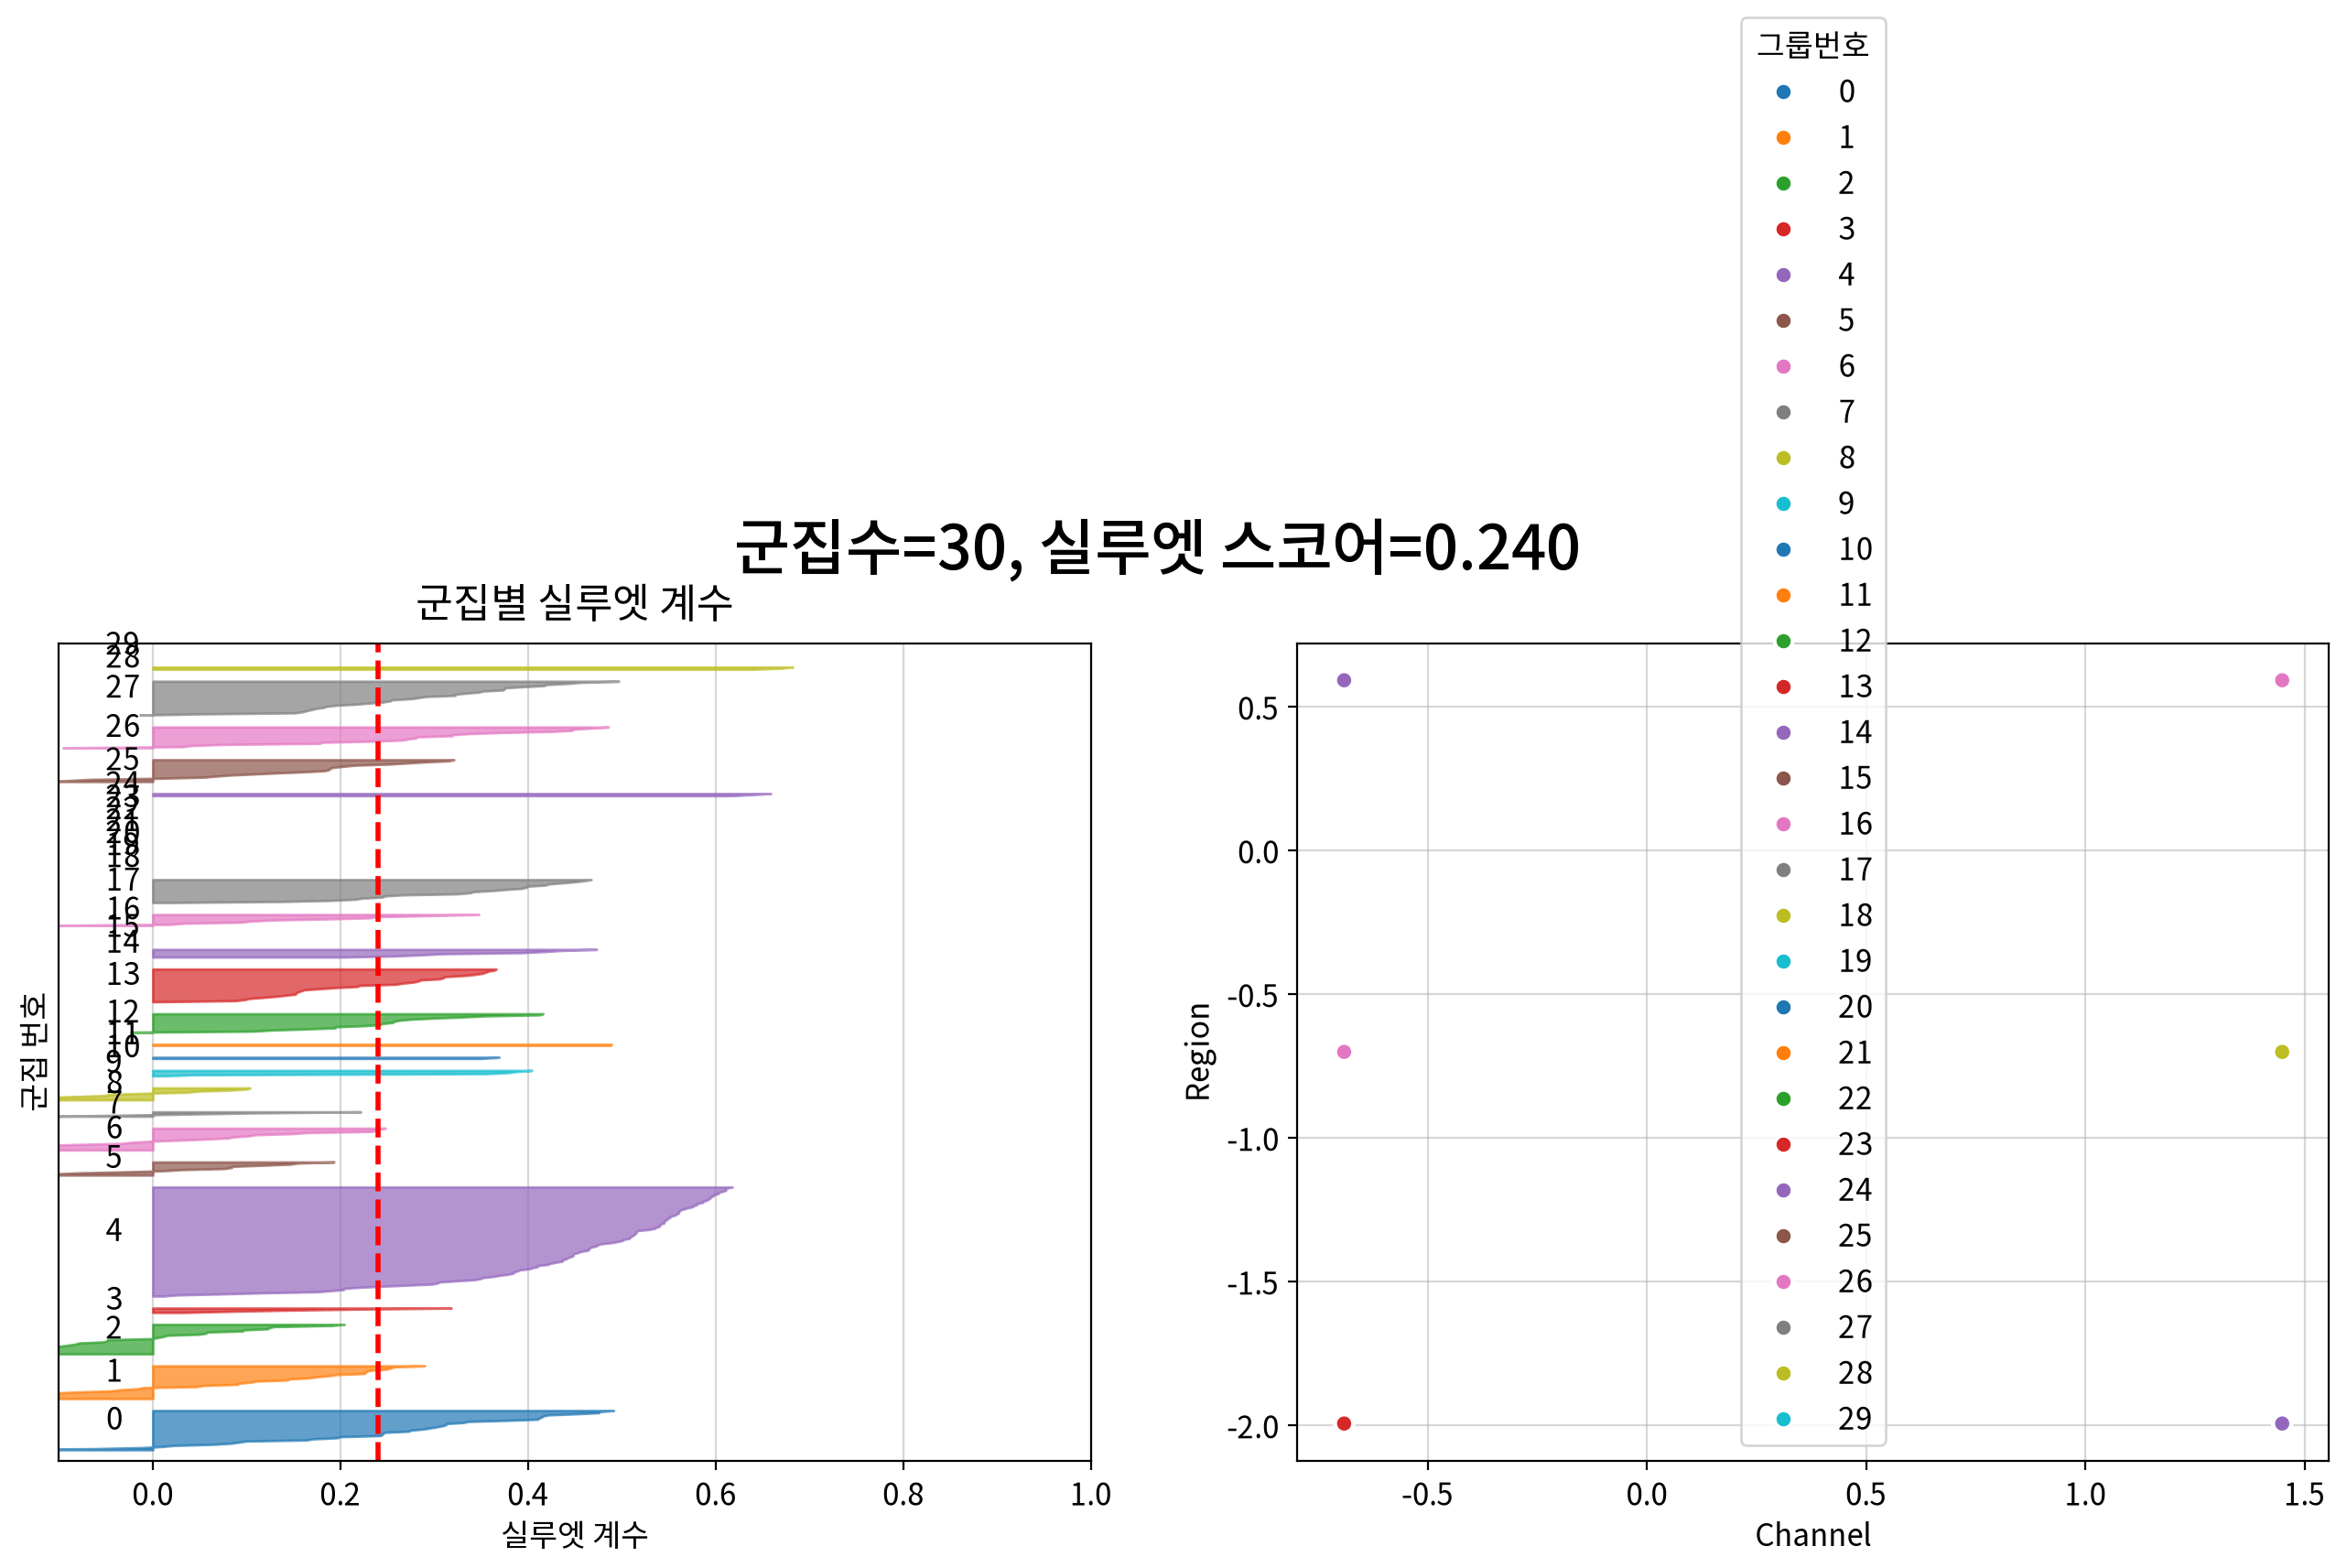

In [19]:
my_cluster.visualize_silhouette(estimator=estimator, data=sdf)


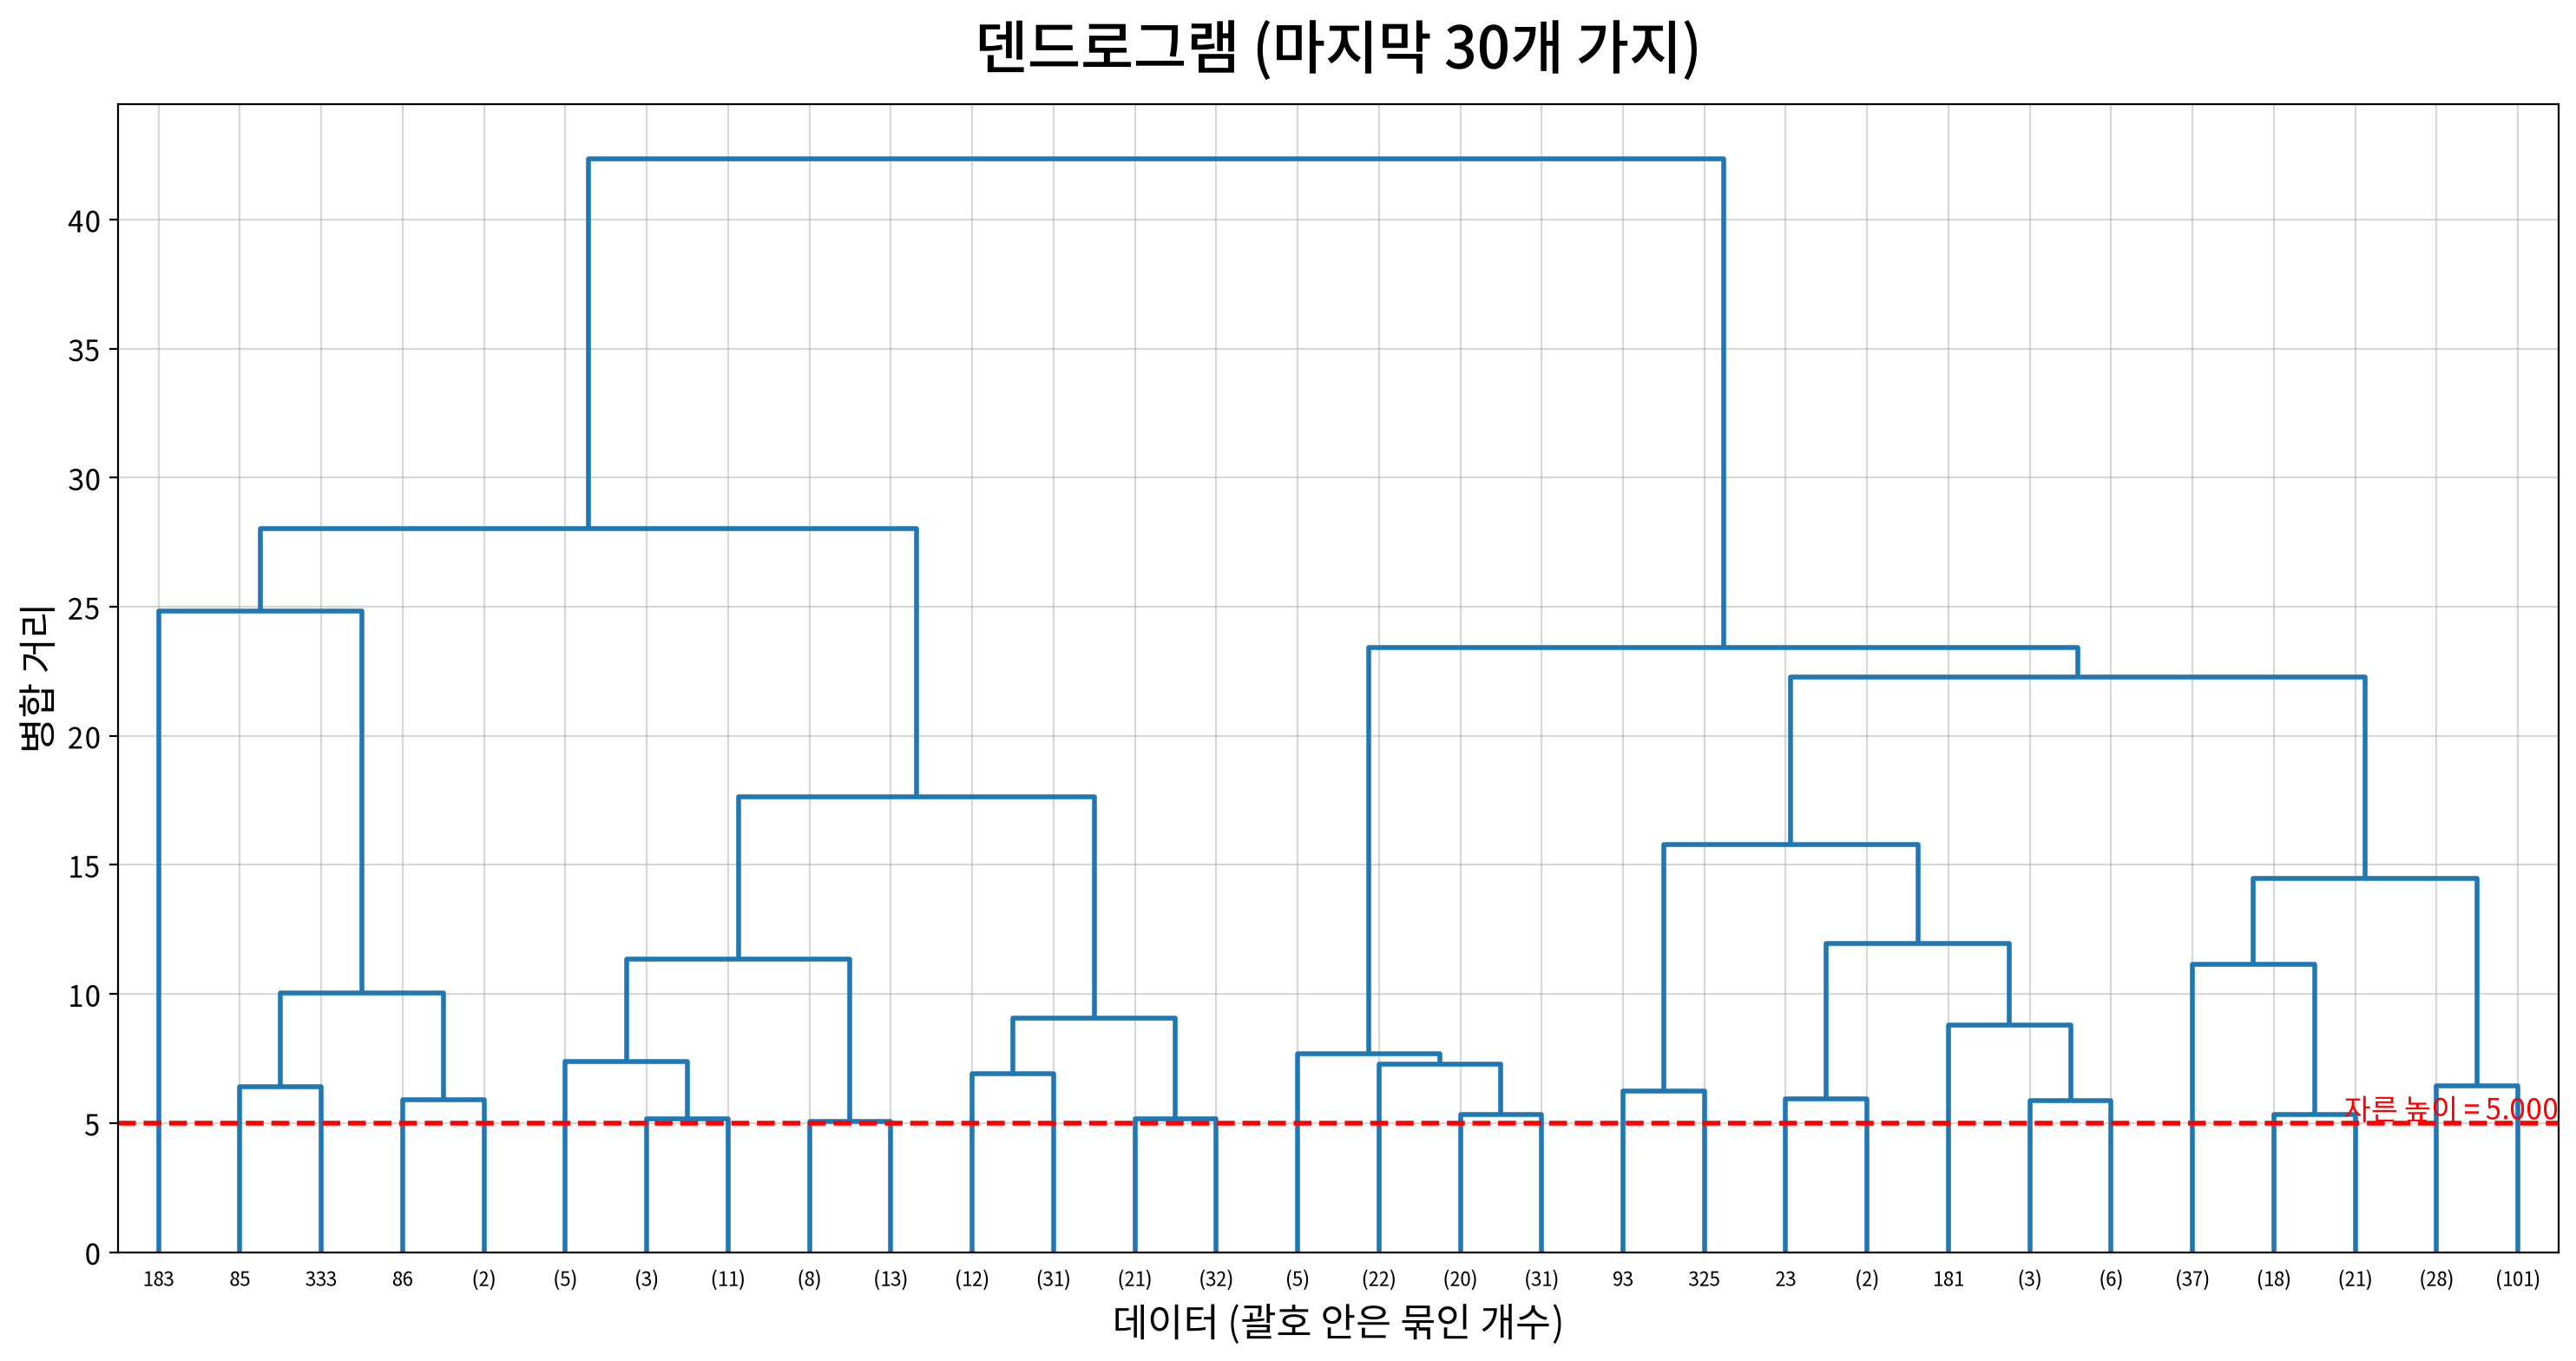

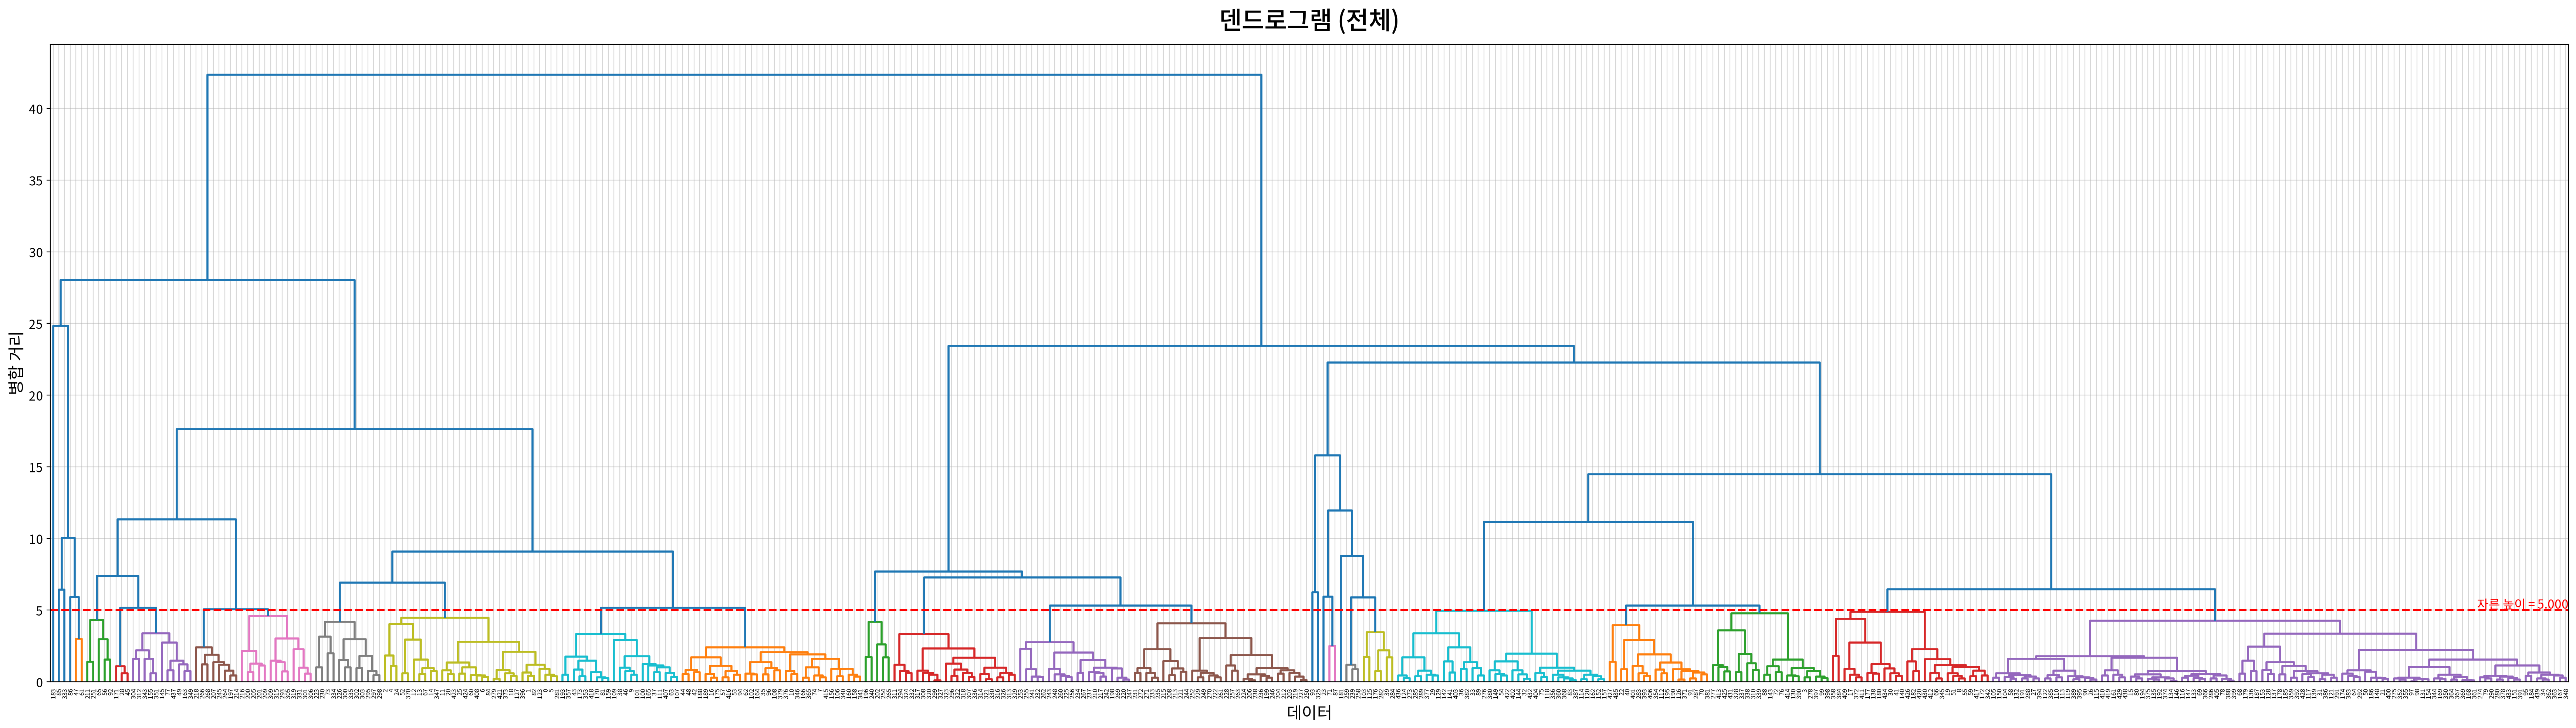

In [ ]:
# #03에서 한 일(linkage 행렬 만들기 -> 캔버스 생성 -> 그리기 -> 축 이름 지정)을 
# 모듈화 함수 하나가 대신한다 
my_cluster.plot_dendrogram(estimator, title="덴드로그램 (마지막 30개 가지)",
                           width=1500, height=800)

# 전체를 보고 싶다면 가지를 생략하지 않도록 truncate_mode를 None으로 지정한다 
my_cluster.plot_dendrogram(estimator, truncate_mode=None, 
                           leaf_rotation=90, leaf_font_size=6,
                           title="덴드로그램 (전체)", width=3500, height=1000)

StandardScaler 적용 (8개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Channel              1.00 ~ 2.00            -0.69~1.45
Region               1.00 ~ 3.00            -2.00~0.59
Fresh           3.00 ~ 112151.00            -0.95~7.93
Milk            55.00 ~ 73498.00            -0.78~9.18
Grocery          3.00 ~ 92780.00            -0.84~8.94
Frozen          25.00 ~ 60869.00           -0.63~11.92
Detergents_Paper     3.00 ~ 40827.00            -0.60~7.97
Delicassen       3.00 ~ 47943.00           -0.54~16.48
[계층적 군집]군집 수 = 8, 연결 방법 = ward, 거리 = euclidean
  . 자른 높이(병합거리) = 15.0000
   . 군집별 데이터 개수: 0번 205개, 1번 5개, 2번 13개, 3번 2개, 4번 78개, 5번 40개, 6번 96개, 7번 1개


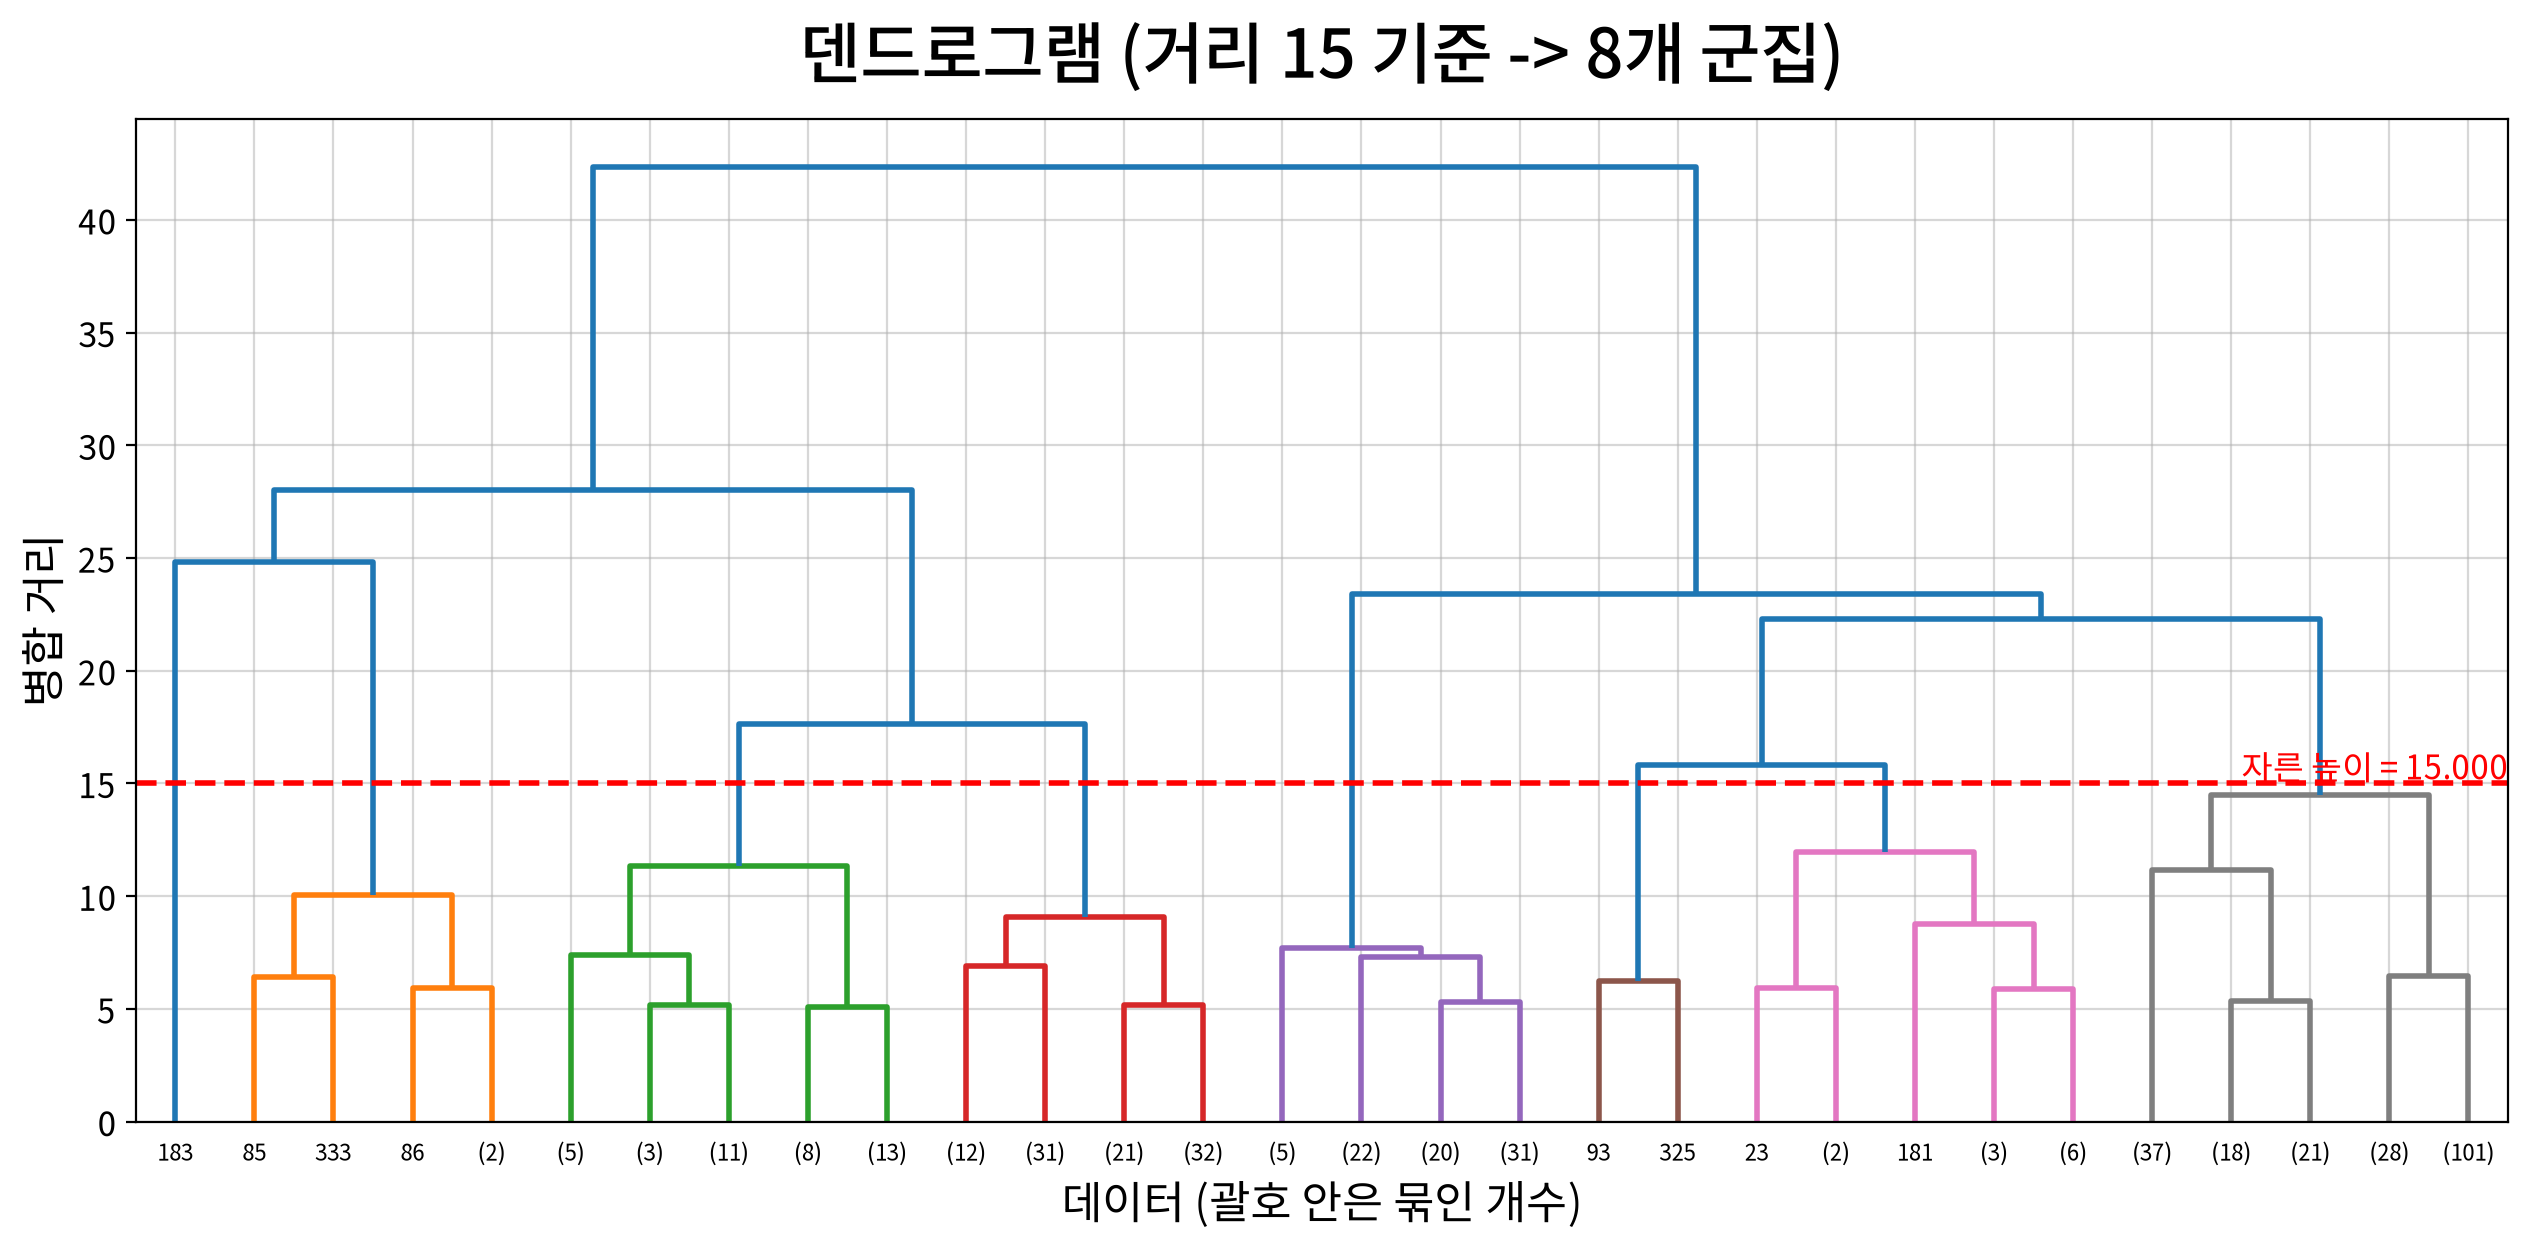

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,그룹번호
0,1.449,0.591,0.053,0.524,-0.041,-0.589,-0.044,-0.066,6
1,1.449,0.591,-0.391,0.544,0.170,-0.270,0.086,0.089,6
2,1.449,0.591,-0.447,0.409,-0.028,-0.138,0.133,2.243,6
3,-0.690,0.591,0.100,-0.624,-0.393,0.687,-0.499,0.093,0
4,1.449,0.591,0.840,-0.052,-0.079,0.174,-0.232,1.299,6


In [ ]:
# 스케일링(기본값 standard)까지 함수가 알아서 수행한다 
estimator, df = my_cluster.agglomerative(origin, distance_threshold=15)
df.head()

StandardScaler 적용 (8개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Channel              1.00 ~ 2.00            -0.69~1.45
Region               1.00 ~ 3.00            -2.00~0.59
Fresh           3.00 ~ 112151.00            -0.95~7.93
Milk            55.00 ~ 73498.00            -0.78~9.18
Grocery          3.00 ~ 92780.00            -0.84~8.94
Frozen          25.00 ~ 60869.00           -0.63~11.92
Detergents_Paper     3.00 ~ 40827.00            -0.60~7.97
Delicassen       3.00 ~ 47943.00           -0.54~16.48
[계층적 군집]군집 수 = 8, 연결 방법 = ward, 거리 = euclidean
  . 자른 높이(병합거리) = 15.1365
   . 군집별 데이터 개수: 0번 205개, 1번 5개, 2번 13개, 3번 2개, 4번 78개, 5번 40개, 6번 96개, 7번 1개


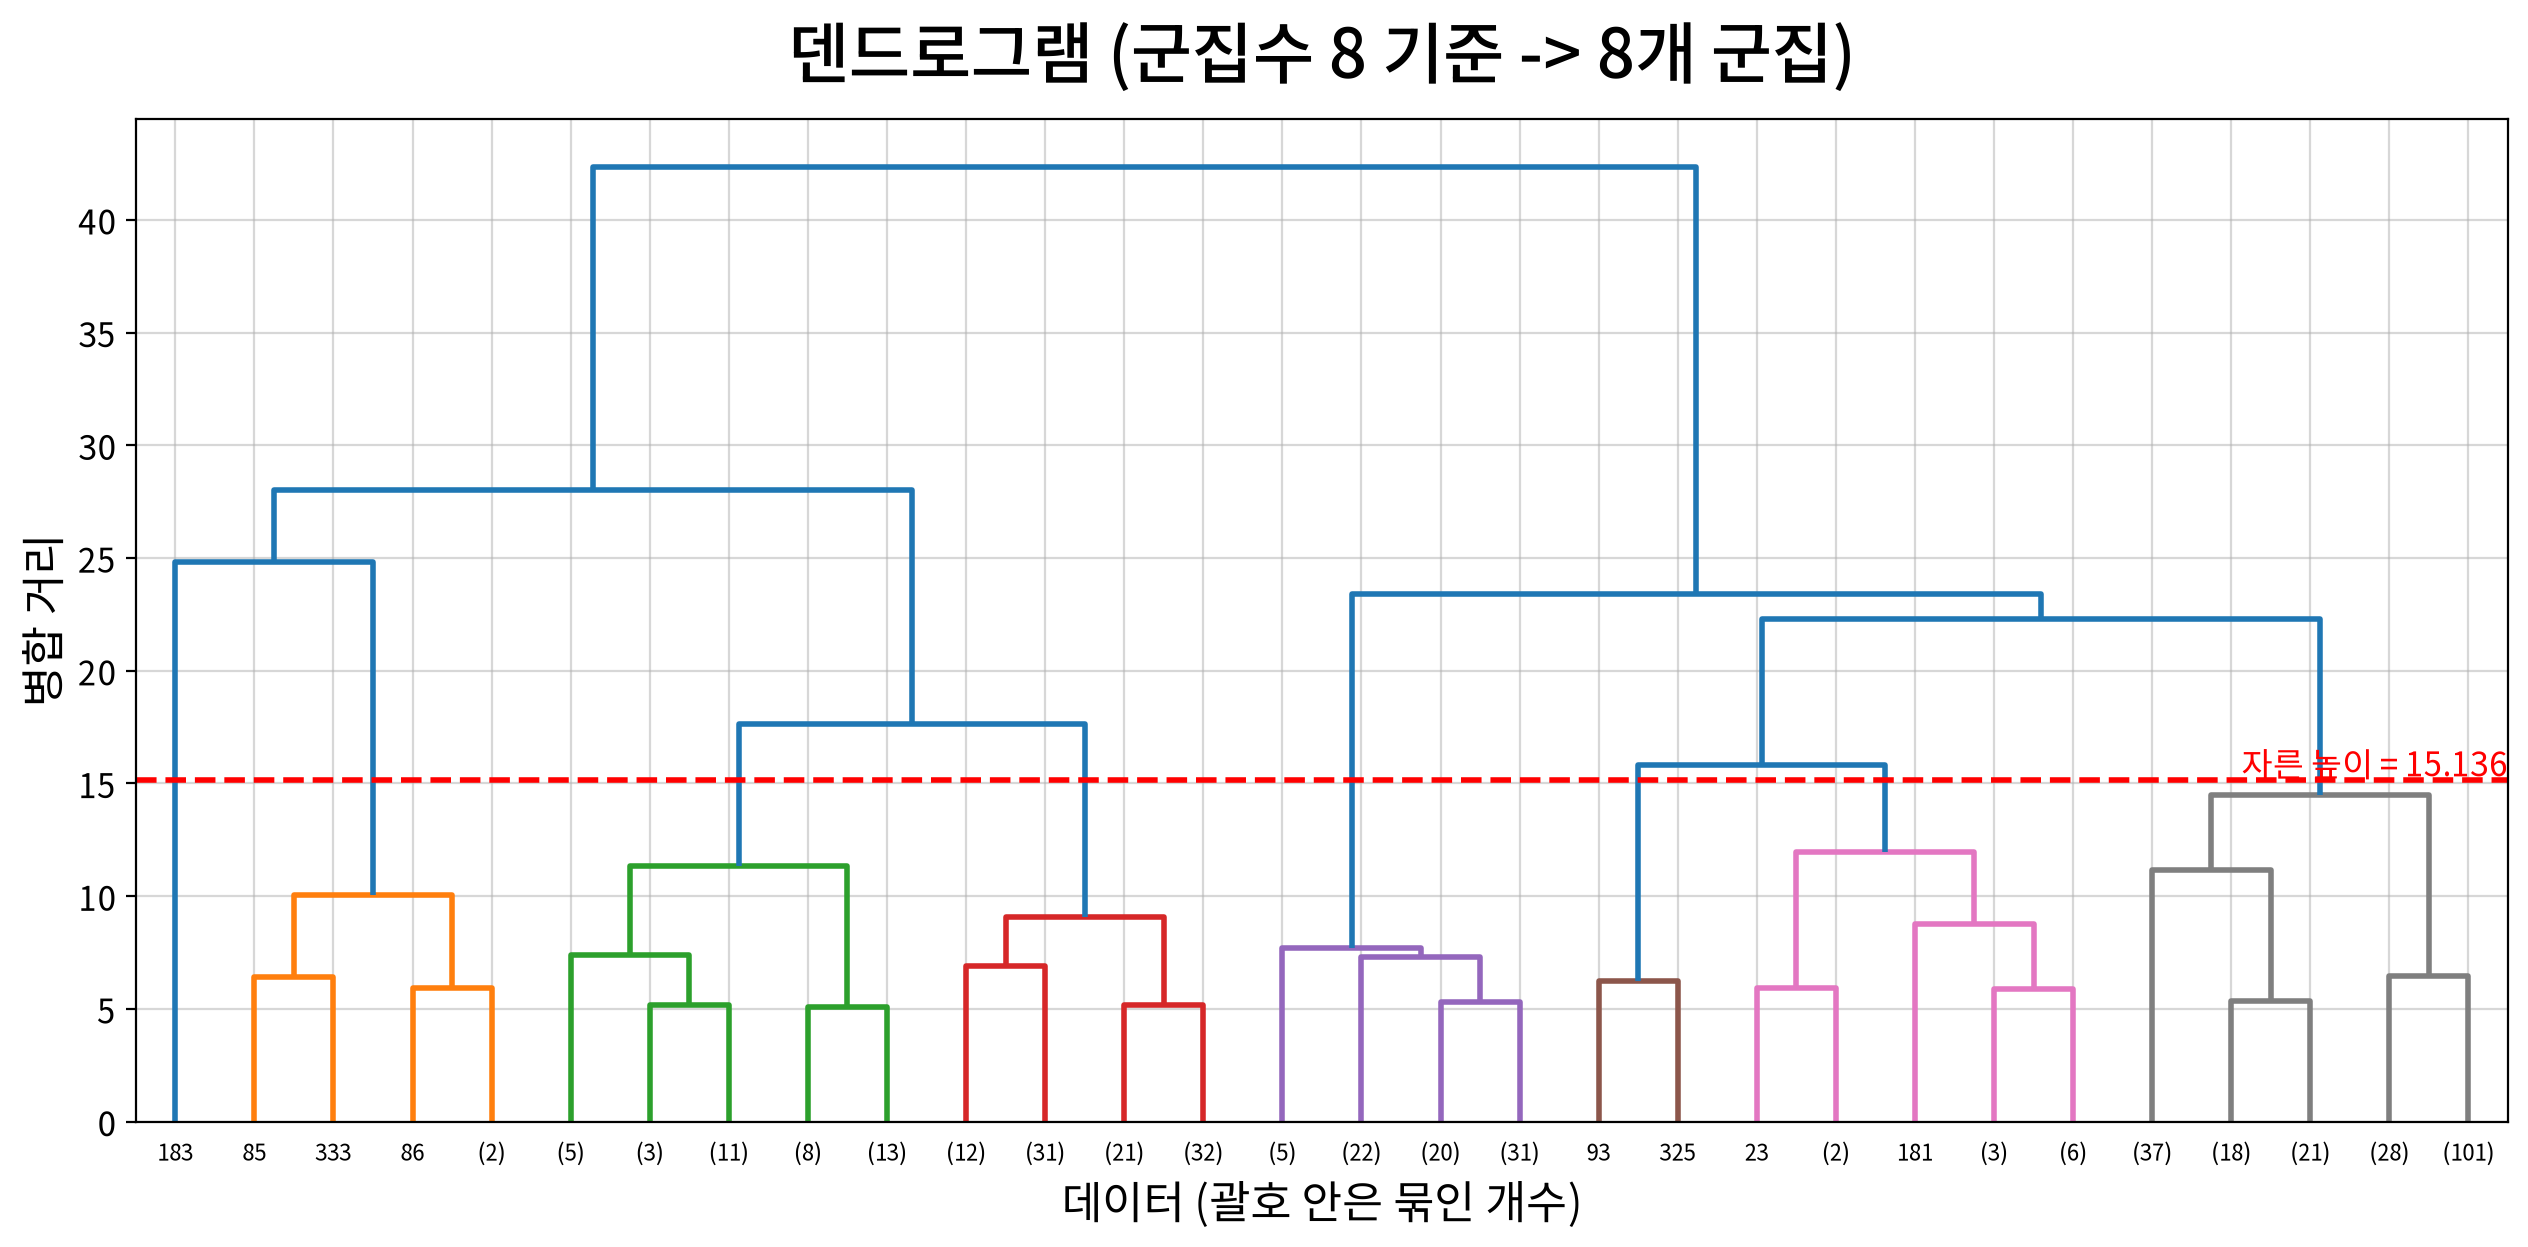

QhullError: QH6013 qhull input error: input is less than 2-dimensional since all points have the same x coordinate 1.449

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 1115643421  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _max-width 2.6  Error-roundoff 1.7e-15  _one-merge 8.5e-15
  _near-inside 4.3e-14  Visible-distance 3.4e-15  U-max-coplanar 3.4e-15
  Width-outside 6.8e-15  _wide-facet 2.1e-14  _maxoutside 1e-14


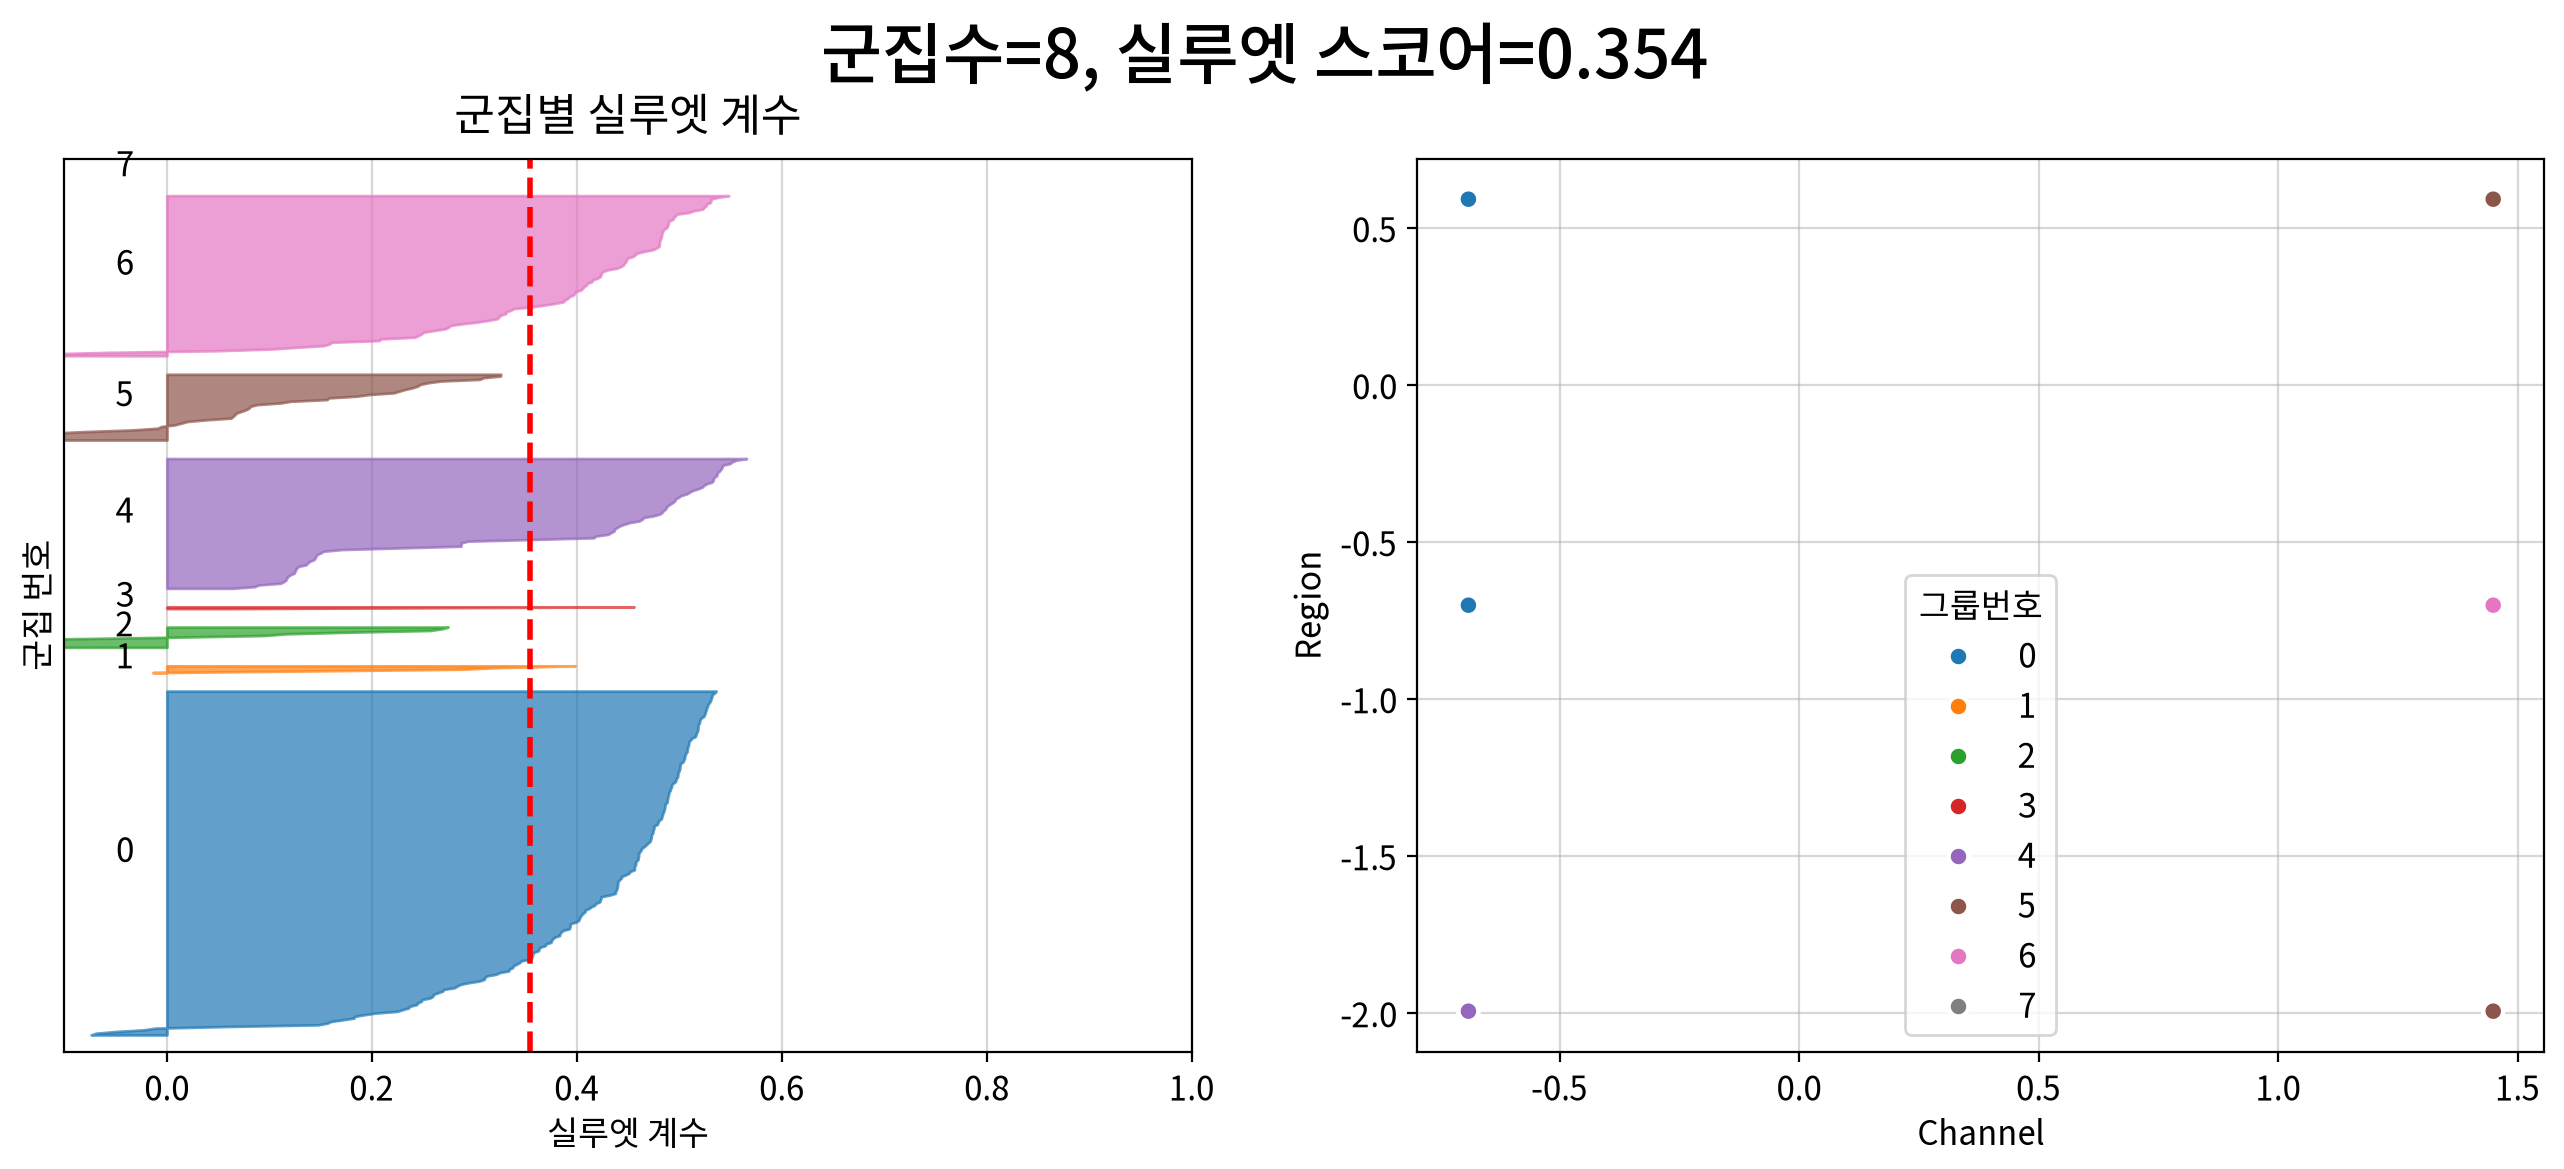

In [ ]:
estimator, df = my_cluster.agglomerative(origin, k=8)

# 실루엣 지수도 함께 확인 (군집번호 컬럼은 함수가 알아서 제외한다)
my_cluster.visualize_silhouette(estimator=estimator, data=df)

## 문제 1
군집 개수를 2~10개로 바꿔 보면, 뭉침만 보는 지표와 뭉침·분리·크기 균형까지 보는 지표가 서로 다른 개수를 가리킵니다. 최종 채택되는 개수는? (정수 1개, 단위: 개)

## 문제 2
개수를 정하지 않고 가까운 거래처끼리 차례로 붙이되, 병합 거리가 15를 넘으면 합치지 않았습니다. 몇 개의 무리로 나뉘나요? (정수 1개, 단위: 개)

## 문제 3
채택한 개수로 두 방법을 돌린 뒤, 가장 많이 겹치는 무리끼리 짝지었습니다. 그 짝에서 어긋난 거래처는 모두 몇 곳인가요? (정수 1개, 단위: 곳)

## 문제 4
두 결과 중 두 무리의 크기가 더 고르게 나뉜 쪽에서, 작은 쪽 무리에 속한 거래처는 몇 곳인가요? (정수 1개, 단위: 곳)

## 문제 5
두 결과를 실제 채널(Horeca / Retail)과 맞춰 볼 때, 일치하는 거래처가 더 많은 쪽은 어느 방법인가요? (방법 이름 1개)

# [LAB-02] 5. 계층적 군집 - 연습문제

## 준비작업

### 라이브러리 참조

In [ ]:
from jussam import load_data
from helpers import *
from pandas import crosstab

## 📚 채널을 모르는 새 거래처를 어느 그룹에 넣을 것인가

### 당신은 식자재 도매 유통업체의 고객관리 담당자입니다.

거래처 440곳이 지난 1년 동안 신선식품·유제품·식료품·냉동식품·세제/종이류·즉석식품 여섯 항목에 각각 얼마를 썼는지가 정리되어 있습니다. 기존 거래처에는 호텔·레스토랑·카페(Horeca)인지 소매점(Retail)인지가 채널 정보로 적혀 있지만, 앞으로 들어올 새 거래처에는 그 정보 없이 주문 내역만 남습니다.

팀장은 "지출 패턴만으로 거래처를 묶어 담당자를 배정하자"고 합니다. 그런데 지난 단원에서 쓰던 KMeans와 이번에 배운 계층적 군집은 **같은 개수로 나눠도 결과가 같지 않다**고 합니다. 참고로 몇몇 큰 거래처의 지출액이 워낙 커서 그대로 거리를 재면 그 거래처들이 결과를 지배하므로, 값의 치우침을 줄여 놓고 시작해야 합니다.

두 방법이 같은 개수로 나눴을 때 결과가 얼마나 달라지는지 확인하고, 담당자 배정에 어느 쪽 결과를 쓸 것인지 판단하세요.

### 💻 코드 작성

#### 데이터 가져오기

In [ ]:
origin = load_data("wholesale_customers")
origin.head()

📚 이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액



,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#### 전처리 (채널·지역 제외 / 지출액의 치우침 줄이기)

In [ ]:
# 채널과 지역은 지출액이 아니라 거래처를 설명하는 정보이므로 거리 계산에서 뺀다
df1 = origin.drop(columns=["Channel", "Region"])

# 몇몇 큰 거래처 때문에 한쪽으로 심하게 치우친 금액을 완만하게 만든다
df2 = my_prep.log_transform(df1, log_columns=list(df1.columns), verbose=False)

print(f"군집분석에 사용할 변수 개수: {df2.shape[1]}개")

df2.head()

군집분석에 사용할 변수 개수: 6개


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.447,9.175,8.931,5.366,7.891,7.199
1,8.862,9.191,9.166,7.474,8.100,7.482
2,8.757,9.083,8.947,7.785,8.165,8.968
3,9.493,7.087,8.348,8.765,6.229,7.489
4,10.026,8.596,8.882,8.273,7.483,8.554


#### 무리 개수 정하기

In [ ]:
final_k, k_df = my_cluster.best_k(df2, plot=False)
k_df

StandardScaler 적용 (6개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Fresh               1.10 ~ 11.63          -5.16 ~ 1.96
Milk                4.01 ~ 11.21          -3.81 ~ 2.86
Grocery             1.10 ~ 11.44          -6.59 ~ 2.69
Frozen              3.22 ~ 11.02          -3.18 ~ 2.90
Detergents_Paper        1.10 ~ 10.62          -3.31 ~ 2.23
Delicassen          1.10 ~ 10.78          -4.25 ~ 3.14
[1단계] 엘보우 포인트   : k = 5  (뭉침만 확인 → 후보)
[2단계] 실루엣 균형지수 : k = 2  (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다.
  · k = 5 : 균형지수 0.0281 (스코어 0.1909, 두께비 1.8519)
  · k = 2 : 균형지수 0.1682 (스코어 0.2896, 두께비 1.328)
------------------------------------------------------------
>>> 최종 선택: k = 2
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


,k,이너셔,감소량,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,1847.995,NaN,0.290,127.418,1.328,0.771,0.168
1,3,1558.090,289.905,0.259,113.770,2.642,0.244,0.024
2,4,1392.488,165.601,0.187,82.232,2.062,0.208,0.019
3,5,1271.310,121.179,0.191,83.994,1.852,0.273,0.028
4,6,1178.638,92.671,0.192,84.525,5.833,0.046,0.002
5,7,1100.517,78.121,0.187,82.205,4.200,0.176,0.008
6,8,1038.942,61.575,0.171,75.407,5.941,0.113,0.003
7,9,987.746,51.196,0.179,78.715,5.529,-0.019,-0.001
8,10,936.833,50.913,0.175,77.005,7.583,0.125,0.003


#### 거리 기준으로 계층적 군집 (덴드로그램)

StandardScaler 적용 (6개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Fresh               1.10 ~ 11.63          -5.16 ~ 1.96
Milk                4.01 ~ 11.21          -3.81 ~ 2.86
Grocery             1.10 ~ 11.44          -6.59 ~ 2.69
Frozen              3.22 ~ 11.02          -3.18 ~ 2.90
Detergents_Paper        1.10 ~ 10.62          -3.31 ~ 2.23
Delicassen          1.10 ~ 10.78          -4.25 ~ 3.14
[계층적 군집] 군집 수 = 4, 연결 방법 = ward, 거리 = euclidean
  · 자른 높이(병합 거리) = 15.0000
  · 군집별 데이터 개수 : 0번 90개, 1번 187개, 2번 116개, 3번 47개


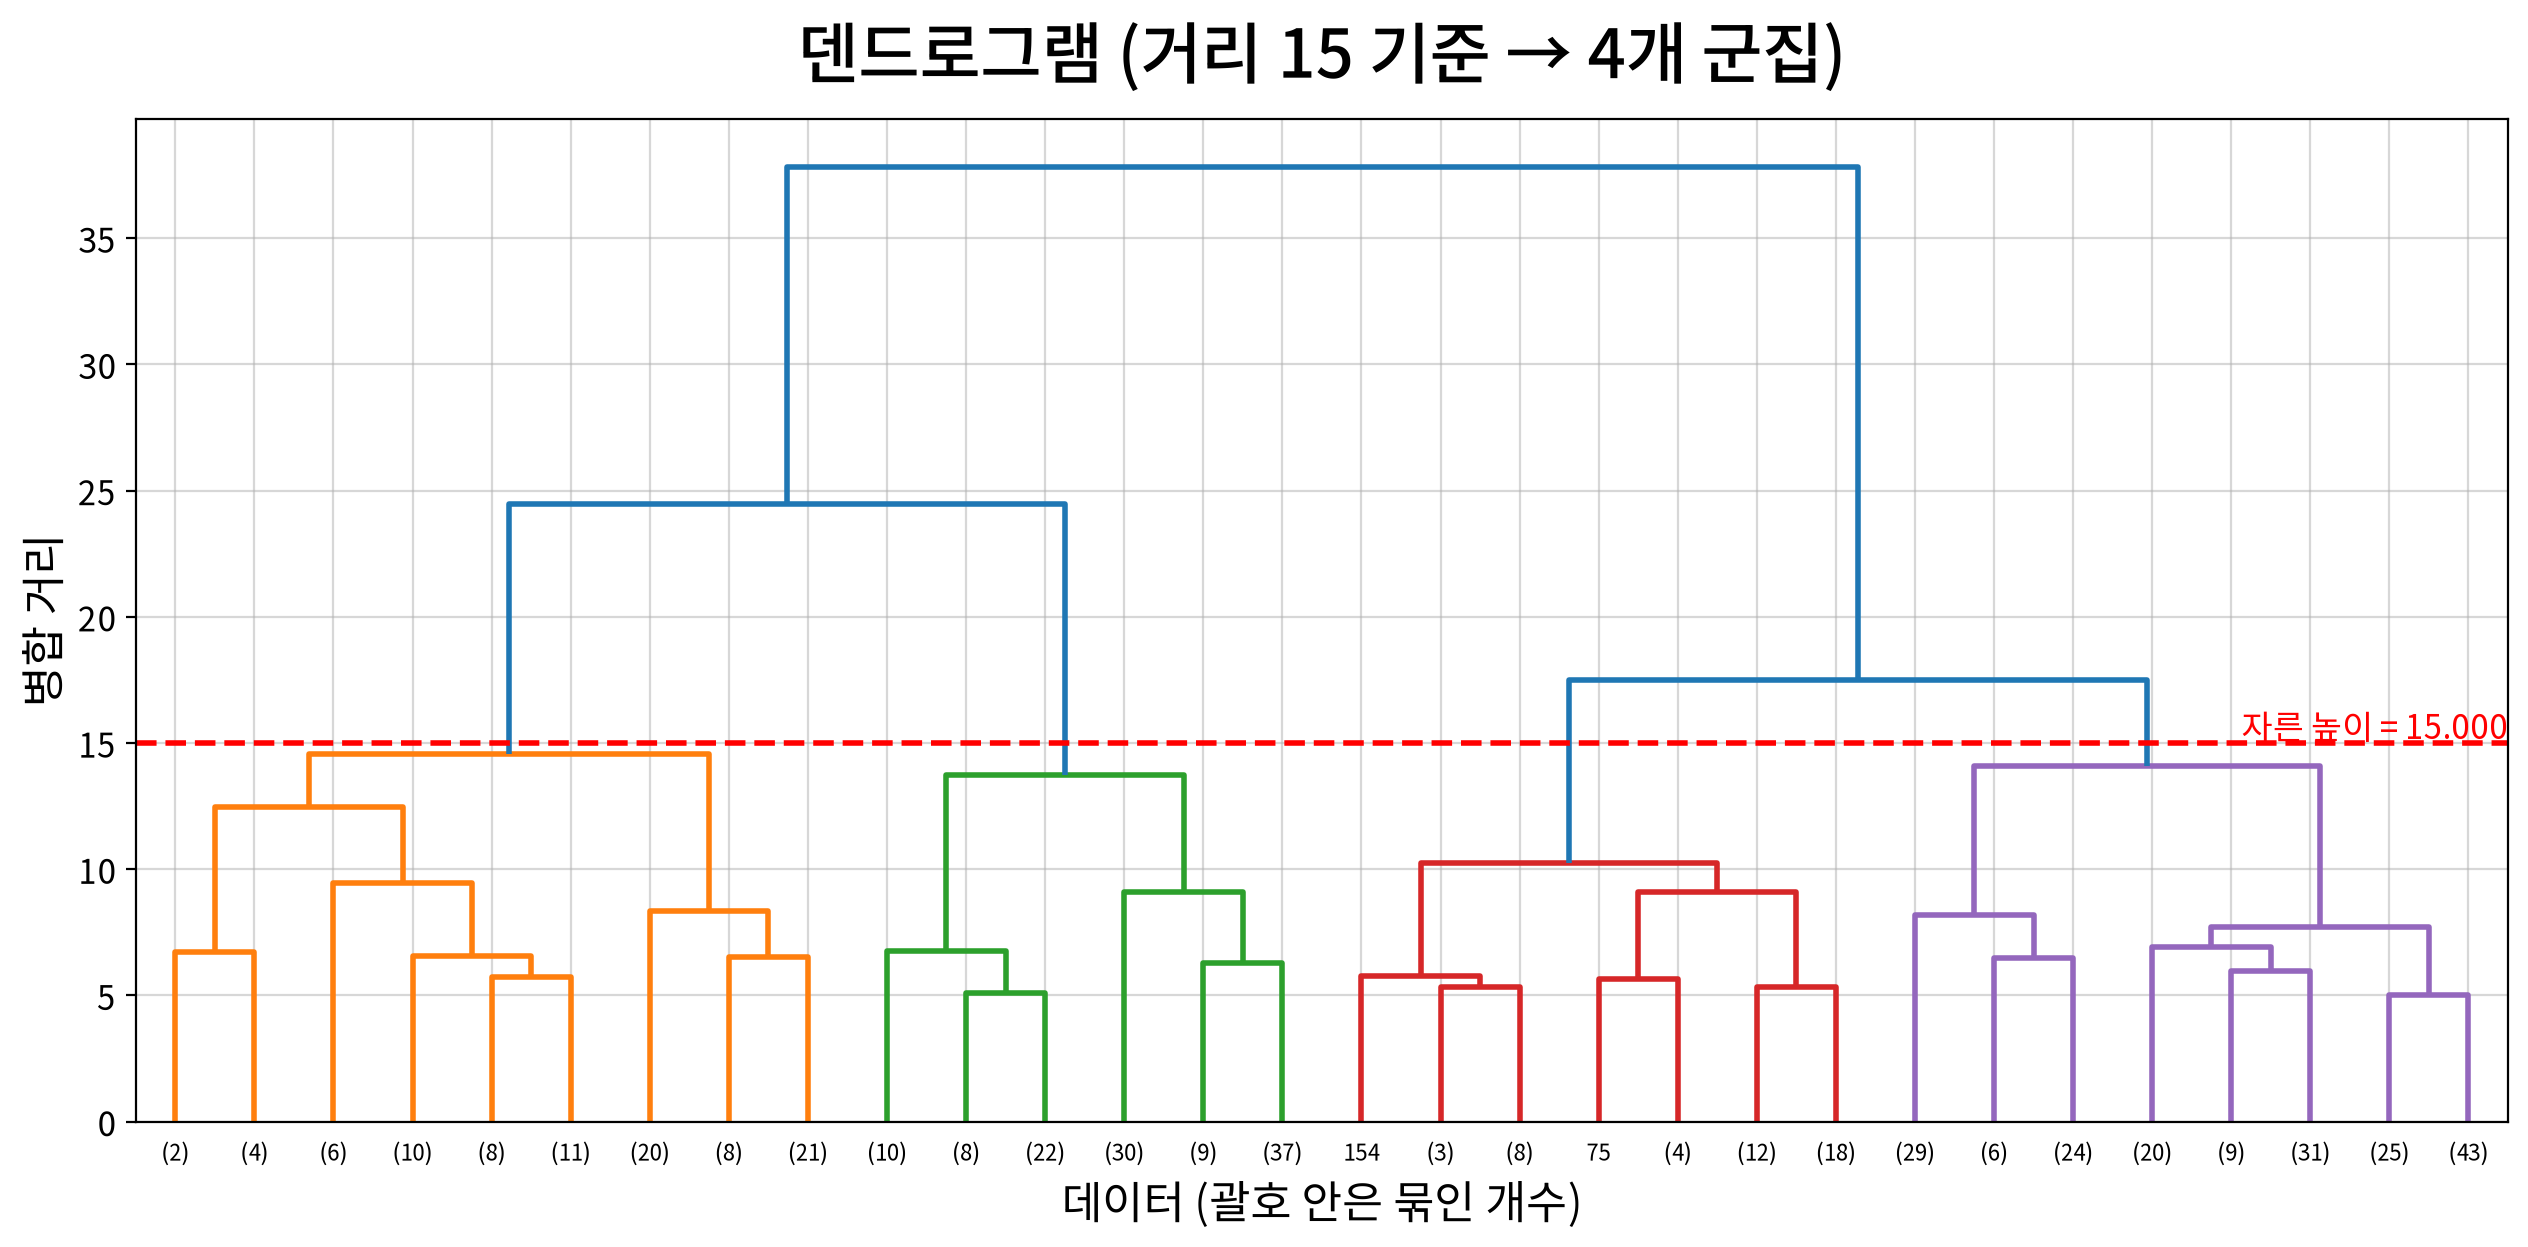

In [ ]:
estimator_d, df_d = my_cluster.agglomerative(df2, distance_threshold=15)

#### 같은 개수로 두 방법을 각각 수행하고 맞대어 보기

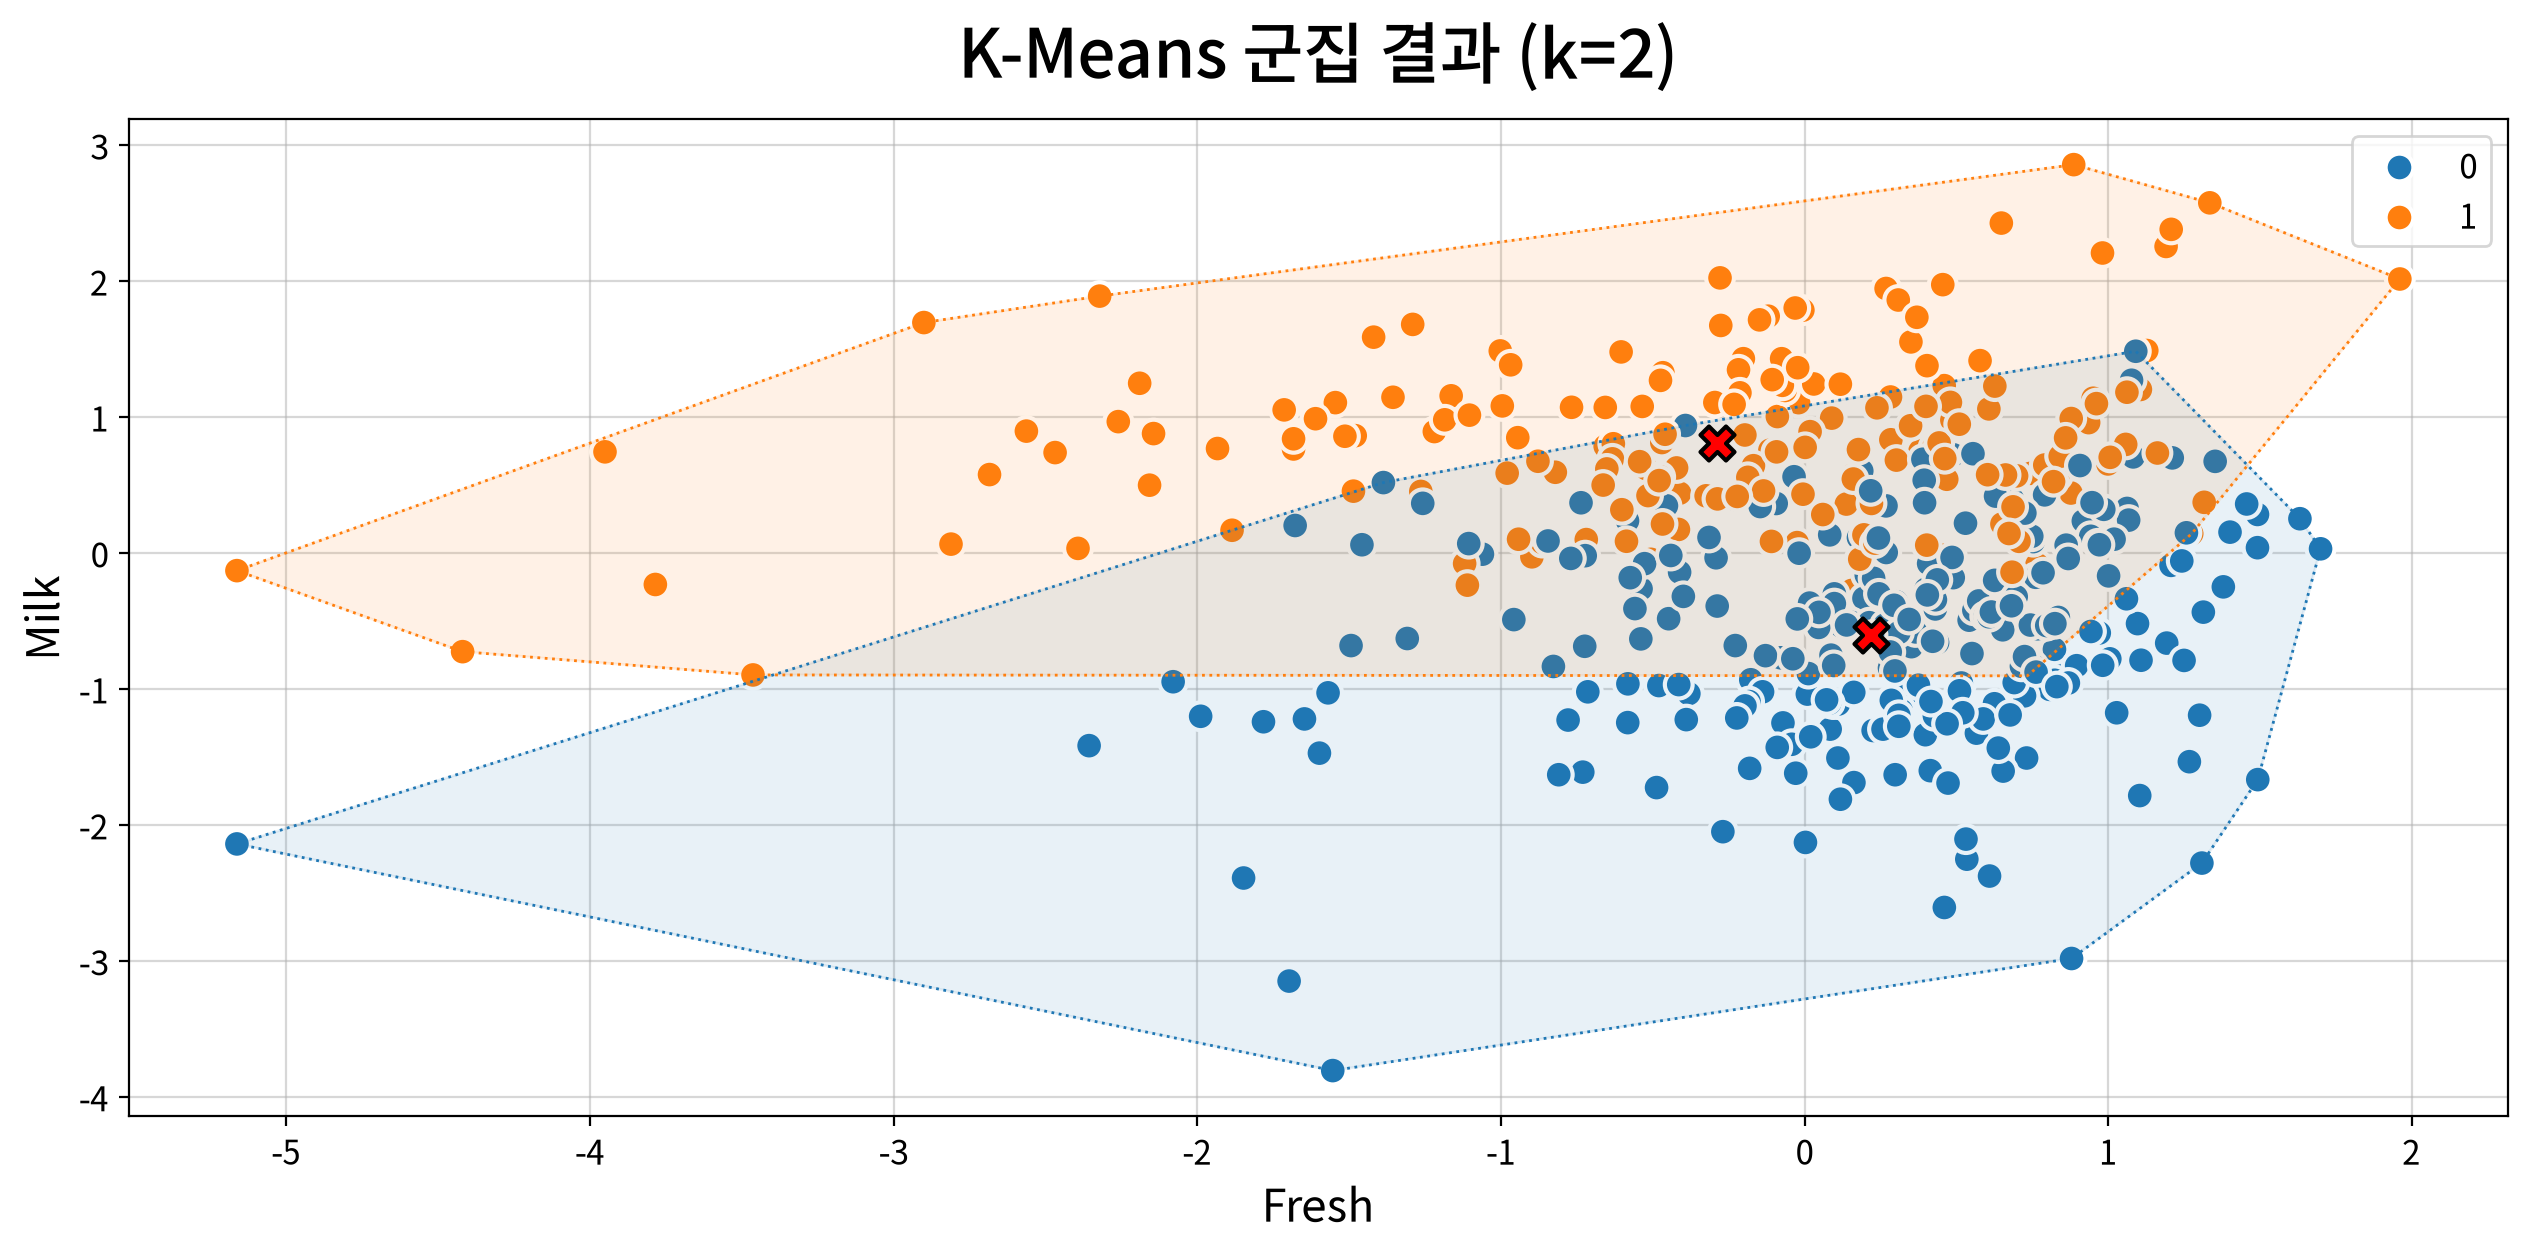

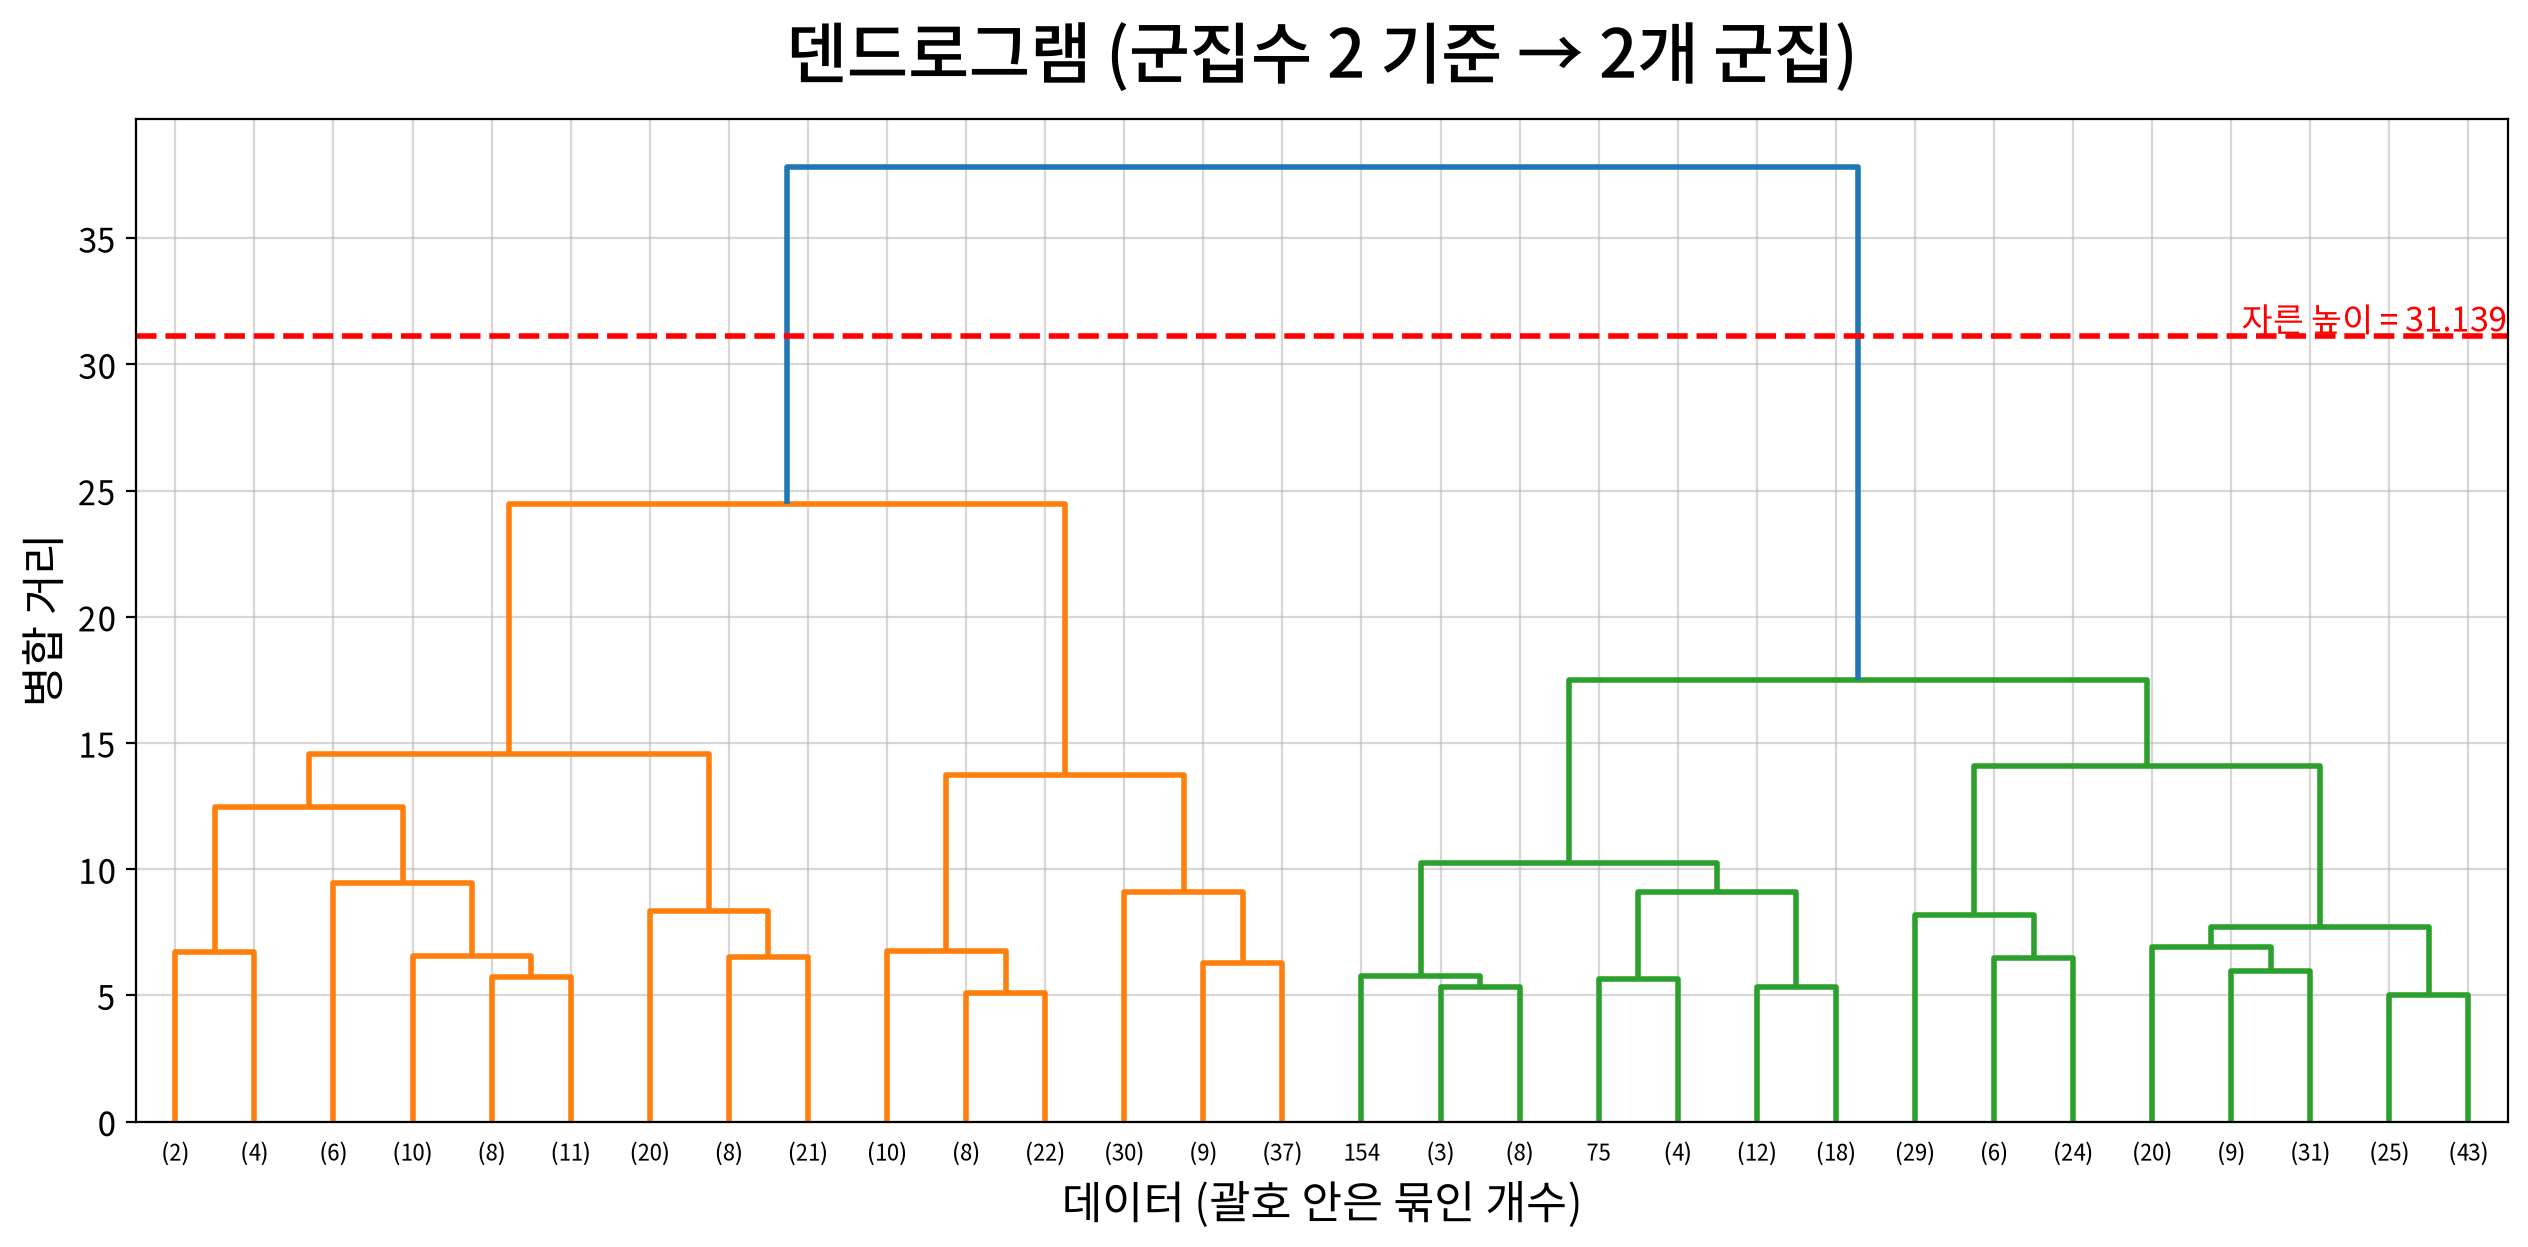


[무리별 거래처 수]
KMeans : {0: 251, 1: 189}
계층적 : {0: 206, 1: 234}

[KMeans(행) × 계층적(열)]
그룹번호    0    1
그룹번호          
0      31  220
1     175   14

두 방법이 서로 다른 무리에 넣은 거래처: 45곳


In [ ]:
estimator_k, df_k, center_df = my_cluster.kmeans(df2, k=final_k, verbose=False)
estimator_h, df_h = my_cluster.agglomerative(df2, k=final_k, verbose=False)

print("\n[무리별 거래처 수]")
print("KMeans :", df_k["그룹번호"].value_counts().sort_index().to_dict())
print("계층적 :", df_h["그룹번호"].value_counts().sort_index().to_dict())

ct = crosstab(df_k["그룹번호"], df_h["그룹번호"])
print("\n[KMeans(행) × 계층적(열)]")
print(ct.to_string())

# 가장 많이 겹치는 무리끼리 짝지었을 때 그 짝에서 어긋난 거래처
print(f"\n두 방법이 서로 다른 무리에 넣은 거래처: {ct.iloc[0, 0] + ct.iloc[1, 1]}곳")

#### 기존 거래처의 실제 채널과 대조

In [ ]:
ct_k = crosstab(df_k["그룹번호"], origin["Channel"])
ct_h = crosstab(df_h["그룹번호"], origin["Channel"])

print("[KMeans × 실제 채널]")
print(ct_k.to_string())
print("\n[계층적 × 실제 채널]")
print(ct_h.to_string())

print(f"\nKMeans 일치 거래처 : {ct_k.max(axis=1).sum()}곳")
print(f"계층적 일치 거래처 : {ct_h.max(axis=1).sum()}곳")

[KMeans × 실제 채널]
Channel    1    2
그룹번호             
0        244    7
1         54  135

[계층적 × 실제 채널]
Channel    1    2
그룹번호             
0         71  135
1        227    7

KMeans 일치 거래처 : 379곳
계층적 일치 거래처 : 362곳


### 문제 풀이

#### 1. 무리 개수를 2개부터 10개까지 바꿔 가며 확인해 보면, 뭉침만 보는 지표가 가리키는 개수와 뭉침·분리·크기 균형까지 함께 보는 지표가 가리키는 개수가 서로 다릅니다. 최종적으로 채택되는 개수는 몇 개인가요? (개)

- **정답**: `2`
- **복습 개념**: 최적 무리 개수를 정하는 두 지표의 역할 분담입니다. 뭉침의 정도(이너셔)가 꺾이는 지점은 후보를 좁혀 줄 뿐이고, 뭉침·분리·크기 균형을 모두 반영한 값이 최종 근거가 됩니다. 계층적 군집도 결국 "몇 개로 나눌까"를 정해야 하므로, 지난 단원의 이 절차를 그대로 씁니다.
- **풀이 접근**: 2개부터 10개까지 나눠 보며 무리 안이 얼마나 촘촘한지, 옆 무리와 얼마나 떨어져 있는지, 무리 크기가 고른지를 개수별로 모읍니다. 그다음 세 가지를 함께 반영한 값이 가장 큰 행의 개수를 읽습니다.
- **근거(계산 결과)**: 뭉침만 보는 지표는 5개를 가리키지만, 세 가지를 함께 본 값은 2개일 때 0.168로 가장 크고 5개일 때는 0.028에 그칩니다. 출력의 `[1단계] 엘보우 포인트 : k = 5`, `[2단계] 실루엣 균형지수 : k = 2`, `>>> 최종 선택: k = 2`로 확인됩니다.
- **헷갈리기 쉬운 점**: 먼저 계산된 5를 답으로 적기 쉽습니다. 뭉침의 정도는 각 무리가 자기 중심 가까이 모여 있는지만 볼 뿐, 옆 무리와 떨어져 있는지도 무리 크기가 한쪽으로 쏠렸는지도 보지 않습니다. 출력이 굳이 5를 "후보"라고 적어 둔 이유가 여기에 있습니다.

#### 2. 이번에는 개수를 정해 주지 않고, 가까운 거래처끼리 차례로 붙여 나가되 병합 거리가 15를 넘으면 더 이상 합치지 않도록 했습니다. 거래처는 몇 개의 무리로 나뉘나요? (개)

- **정답**: `4`
- **복습 개념**: 계층적 군집에서 나무를 자르는 두 가지 방법 중 "거리 기준"입니다. 개수를 사람이 정해 넣는 대신 "이만큼 멀면 남남으로 둔다"는 기준만 주면, 무리의 개수는 데이터가 정합니다. KMeans에는 없는 방식입니다.
- **풀이 접근**: 합칠 수 있는 최대 거리를 15로 두고 계층적 군집을 수행한 뒤, 만들어진 무리의 개수를 확인합니다. 덴드로그램에서 높이 15에 가로선을 긋고 그 선과 만나는 가지의 수를 세는 것과 같은 이야기입니다.
- **근거(계산 결과)**: 출력의 `[계층적 군집] 군집 수 = 4`이며, 무리별 거래처 수는 187곳·116곳·90곳·47곳입니다. 덴드로그램에도 자른 높이 15가 빨간 점선으로 그려지고, 그 선과 만나는 가지가 정확히 **4개**입니다.
- **함께 생각해 볼 점**: 기준을 20으로 올리면 3개, 10으로 내리면 9개가 됩니다. 거리 기준은 개수를 대신 정해 주는 것이 아니라 "얼마나 비슷해야 같은 무리로 볼 것인가"를 정하는 일입니다. 담당자를 4명 둘 수 있는지 9명 둘 수 있는지는 지표가 아니라 조직 사정이 정합니다.

#### 3. 앞에서 채택한 개수로 두 방법을 각각 돌린 뒤 두 결과를 맞대어, 가장 많이 겹치는 무리끼리 짝지었습니다. 그 짝에서 어긋난 — 즉 두 방법이 서로 다른 무리에 넣은 — 거래처는 모두 몇 곳인가요? (곳)

- **정답**: `45`
- **복습 개념**: 같은 개수로 나눠도 방법이 다르면 결과가 달라진다는 사실을 숫자로 확인하는 단계입니다. 두 결과를 비교할 때는 교차표를 만들되, 무리 번호 자체는 아무 의미가 없어 0번과 0번이 같은 무리라는 보장이 없다는 점에 주의해야 합니다.
- **풀이 접근**: 두 방법의 무리 번호로 교차표를 만들면 2×2 표가 나옵니다. 값이 큰 칸 두 개가 서로 대응하는 짝이고, 나머지 두 칸이 두 방법의 판단이 갈린 거래처입니다. 그 두 칸을 더합니다.
- **근거(계산 결과)**: 교차표는 KMeans 0번 무리가 계층적 1번과 220곳, KMeans 1번이 계층적 0번과 175곳 겹칩니다. 짝에서 벗어난 칸은 31곳과 14곳이므로 31 + 14 = **45곳**입니다. 출력의 `두 방법이 서로 다른 무리에 넣은 거래처: 45곳`으로 확인됩니다.
- **자주 하는 실수**: 번호가 같은 칸(0-0과 1-1)을 일치로 보고 31 + 14를 "맞은 개수"로 세면 정반대의 답이 나옵니다. 군집분석의 무리 번호는 이름표일 뿐 순서도 의미도 없습니다. 두 결과를 비교할 때는 항상 겹치는 양이 가장 큰 칸끼리 짝을 지어 놓고 시작하세요.

#### 4. 같은 개수로 나눈 두 결과 중, 두 무리의 크기가 더 고르게 나뉜 쪽에서 작은 쪽 무리에 속한 거래처는 몇 곳인가요? (곳)

- **정답**: `206`
- **복습 개념**: 두 방법이 무리를 만드는 원리의 차이가 크기에서 드러나는 지점입니다. KMeans는 중심점을 정해 놓고 가까운 쪽으로 배정하기를 반복하고, 계층적 군집(ward 연결)은 합쳤을 때 흩어짐이 가장 적게 늘어나는 쌍부터 붙여 나갑니다. 후자는 큰 덩어리에 계속 붙이는 것을 손해로 계산하므로 크기가 비교적 고르게 갈립니다.
- **풀이 접근**: 두 방법의 결과에서 각각 무리별 거래처 수를 세어 두 무리의 차이가 작은 쪽을 고르고, 그쪽의 작은 무리 크기를 읽습니다.
- **근거(계산 결과)**: KMeans는 251곳과 189곳(차이 62곳), 계층적은 234곳과 206곳(차이 28곳)으로 나뉩니다. 더 고르게 나뉜 쪽은 계층적이며 작은 무리는 **206곳**입니다. 출력의 `계층적 : {0: 206, 1: 234}`로 확인됩니다.
- **실무 포인트**: 담당자를 두 명 두고 거래처를 나눠 맡긴다면 234 대 206이 251 대 189보다 업무량이 고릅니다. 다만 크기가 고른 것과 잘 나뉜 것은 다른 이야기이므로, 균형만 보고 방법을 고르지는 마세요. 바로 다음 문제에서 이 둘이 갈립니다.

#### 5. 두 결과를 기존 거래처에 이미 적혀 있는 실제 채널(호텔·레스토랑·카페 / 소매점)과 각각 맞춰 보면, 실제 채널 구분과 일치하는 거래처가 더 많은 쪽은 어느 방법인가요?

- **정답**: `KMeans`
- **복습 개념**: 군집 결과를 이미 알고 있는 라벨과 대조해 해석하는 마지막 단계입니다. 군집분석은 정답을 모르고 수행하지만, 정답이 남아 있는 데이터라면 사후에 맞춰 보며 "이 무리가 무엇인가"를 읽고 방법을 고를 수 있습니다.
- **풀이 접근**: 각 방법의 무리 번호와 분석에서 빼 두었던 채널 정보로 교차표를 만들고, 무리마다 가장 많이 몰린 채널의 거래처 수를 더해 두 방법을 비교합니다.
- **근거(계산 결과)**: KMeans는 한 무리가 Horeca 244곳, 다른 무리가 Retail 135곳으로 합계 **379곳**이 일치합니다. 계층적은 227곳 + 135곳으로 362곳입니다. 출력의 `KMeans 일치 거래처 : 379곳`, `계층적 일치 거래처 : 362곳`으로 확인됩니다.
- **결론**: 당신이 팀장에게 보고할 내용은 "계층적 군집이 더 좋다"가 아닙니다. 같은 2개로 나눴는데도 45곳의 소속이 갈렸고, 계층적은 크기를 고르게 나눈 대신 실제 채널과는 17곳 덜 맞았습니다. 새 거래처의 채널을 지출 패턴으로 추정하는 것이 목적이라면 채널을 더 잘 복원한 KMeans 결과를, 담당자 업무량을 고르게 배분하는 것이 목적이라면 계층적 결과를 씁니다. 무엇보다 계층적 군집은 개수를 미리 정하지 않고 덴드로그램에서 자를 높이를 바꿔 가며 4개·9개로도 볼 수 있으므로, 팀 규모가 정해지지 않은 지금 단계에서는 이 그림을 함께 들고 가는 편이 낫습니다.